# Building a Neural Network from Scratch: The NumPy & Calculus Monolith

Welcome to the machinery. In this notebook, we strip away the comforting abstractions of modern deep learning frameworks. There is no `import torch` to save us, and no `tf.GradientTape` to magically compute derivatives. We are descending to the bare metal of deep learning: raw linear algebra and multivariate calculus.

Our objective is to construct a multi-layer perceptron entirely from scratch. Every forward pass, every activation function, and most crucially, every backward pass of the gradient will be explicitly defined. By manually wiring the calculus that dictates how weights update in response to error, you will gain an uncompromising, first-principles understanding of how neural networks actually learn. We are not just training a model; we are building the engine itself.


## How to read this monolith

This notebook is a textbook that executes. Every phase is written so that a later cell may legally *redefine* a class you already met. That is not sloppiness. It is the same move a research codebase makes when it pays down technical debt: keep the historical artifact, then replace the engine.

**What this project is**

- A from-scratch multilayer perceptron: forward pass, reverse-mode autodiff, SGD with momentum, He/Xavier init, mini-batching, fused softmax-cross-entropy, and a raw IDX parser for MNIST.
- An educational instrument for three audiences at once: the beginner who has never written `dW = X.T @ dZ`, the intermediate practitioner who has called `loss.backward()` for years without deriving it, and the person writing a statement of purpose who needs to *show* they can build the engine, not only import it.

**What this project is not**

- Not a deep learning framework. There is no autograd graph, no CUDA kernel, no convolution.
- Not "dependency-free" in the literal sense. The learning engine is **NumPy-only**. Matplotlib is used for figures. Manim Community is *optional* and used for three cinematic scenes. There is no PyTorch, no TensorFlow, no Keras, no scikit-learn.

**How to run**

1. `pip install numpy matplotlib jupyter`
2. Optional cinematics: `pip install manim` and a working `ffmpeg` on `PATH`
3. `jupyter notebook Neural_Network_From_Scratch.ipynb` and **Run All**
4. The first time, MNIST `.gz` files are downloaded and SHA-256 checked against the TensorFlow Datasets checksums

**What you will be able to do when you finish**

- Derive $\partial L/\partial W$, $\partial L/\partial b$, $\partial L/\partial X$ from the chain rule without guessing shapes
- Explain why a 100-layer linear network is one linear layer
- Prove an implementation with *numerical* gradient checking, not vibes
- State, precisely, why $\partial L/\partial Z = (P - Y)/N$ for softmax + cross-entropy
- Look at a training curve and tell overfitting from undertraining

If a cell looks like a "crisis," it is. Read the markdown above it before you skip to the code.


## Contents

Jump around. Later cells are allowed to replace earlier classes; that is the curriculum.

1. [The Prerequisites](#1-the-prerequisites-what-you-need-to-know)
2. [Architectural Blueprint](#2-architectural-blueprint)
3. [Object-Oriented Deep Learning](#3-the-architecture-object-oriented-deep-learning)
4. [Activation Functions](#4-the-non-linear-engine-activation-functions)
5. [Loss Functions](#5-the-compass-loss-functions)
6. [Backpropagation](#6-the-backpropagation-engine-time-travel-via-calculus)
7. [The Network API](#7-the-network-api-orchestrating-the-layers)
8. [XOR](#8-the-acid-test-the-xor-problem)
9. [Decoupling calculus from optimization](#9-professional-engineering-decoupling-calculus-from-optimization)
10. [SGD and momentum](#10-the-optimizer-sgd-and-momentum)
11. [Initialization](#11-the-initialization-crisis-vanishing-and-exploding-gradients)
12. [Mini-batches](#12-data-pipelines-the-power-of-mini-batches)
13. [Accuracy](#13-human-vs-machine-metrics)
14. [The training loop](#14-the-orchestrator-the-training-loop)
15. [Fused softmax and cross-entropy](#15-the-final-boss-fusing-softmax-and-cross-entropy)
16. [IDX parser](#16-the-dependency-free-vow-parsing-raw-idx-files)
17. [MNIST run](#17-assembly-and-execution)
18. [Pictures of the result](#18-the-proof-visualizing-the-matrix-space)

Cinematics sit next to the math they illustrate: Affine Loom, Blame Telegraph, Jacobian Collapse, the legal contraction, and the dead net.


## Map of the hour

You will write a Dense layer, a Tanh, and an MSE by hand. You will watch XOR sit at `0.5` because the weights are tiny. You will switch to Xavier and watch the four points snap. You will parse MNIST IDX files, train **40 epochs**, and land near 98 percent on the test set. Train accuracy will hit 100 percent. That gap is overfitting.

If a cell looks like a crisis, it is. Read the markdown above it.


## 1. The Prerequisites: What You Need to Know

### Linear Algebra

At its core, a neural network is an execution of sequential matrix transformations. A single layer performs a linear transformation followed by a non-linear activation. The fundamental operation is:

$$
Y = XW + b
$$

Where data flowing through the network is fundamentally just matrices shifting through higher-dimensional spaces.

### Calculus (The Chain Rule)

Learning is simply mathematical optimization. We compute an error scalar (the loss) and determine how every single parameter in our massive matrix topology contributed to that error. We propagate this blame backward using the Chain Rule of calculus:

$$
\frac{\partial z}{\partial x} = \frac{\partial z}{\partial y} \cdot \frac{\partial y}{\partial x}
$$

### Recommended God-Tier Resources for the Uninitiated

If the mechanics above feel abstract, step back and internalize the theory. Do not proceed until you can visualize these concepts:

- **3Blue1Brown's 'Neural Networks' YouTube playlist**: Crucial for building a spatial and visual intuition of matrix transformations, weight spaces, and gradient descent.
- **Andrej Karpathy's 'Micrograd' video**: The ultimate deconstruction of backpropagation. Watch this to understand the raw essence of reverse-mode autodifferentiation at the scalar level.


### These are prerequisites, not optional atmosphere

If matrix multiplication, broadcasting, or the chain rule still feel like slogans, stop here and actually watch the two resources above. The rest of this notebook will not "click" by osmosis.

A compact self-test before Phase 2:

1. Why is $(AB)^\top = B^\top A^\top$ the identity that makes $\mathrm{d}W = X^\top\,\mathrm{d}Z$ the *only* legal contraction?
2. Why does adding a vector of shape `(F,)` to a matrix of shape `(N, F)` sometimes silently transpose in your head even when NumPy "works"?
3. Write $\frac{\partial}{\partial x} f(g(x))$ and then name $f$ as "the loss" and $g$ as "the layer." That is backpropagation.

If you cannot answer (1) on paper, you are not ready to debug a shape error at 1 a.m. That is the point of this notebook: you will be able to.


In [3]:
import numpy as np
import matplotlib.pyplot as plt  # strictly for visualization at the end, not for network architecture

# Setting the seed. In a universe of randomness, we demand reproducibility for debugging.
np.random.seed(42)


In [ ]:
from pathlib import Path
from IPython.display import display, Image, Video, Markdown

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
MANIM_DIR = Path("visualizations/rendered")

# Optional: bundled ffmpeg from imageio-ffmpeg, if the system has none.
try:
    import os, shutil
    if shutil.which("ffmpeg") is None:
        import imageio_ffmpeg
        ffdir = str(Path(imageio_ffmpeg.get_ffmpeg_exe()).parent)
        os.environ["PATH"] = ffdir + os.pathsep + os.environ.get("PATH", "")
except Exception:
    pass

def dfnn_style():
    """House style for every figure in this notebook."""
    plt.rcParams.update({
        "figure.facecolor": "#0B0F19",
        "axes.facecolor": "#0B0F19",
        "axes.edgecolor": "#2A3A52",
        "axes.labelcolor": "#E8ECF1",
        "axes.titlecolor": "#E8ECF1",
        "text.color": "#E8ECF1",
        "xtick.color": "#8B93A7",
        "ytick.color": "#8B93A7",
        "grid.color": "#1E2A3C",
        "legend.facecolor": "#121826",
        "legend.edgecolor": "#2A3A52",
        "savefig.facecolor": "#0B0F19",
        "savefig.dpi": 160,
        "font.size": 11,
    })

def show_cinematic(mp4_rel, png_rel, caption=""):
    """Display a pre-rendered Manim scene, with a still frame as fallback."""
    if caption:
        display(Markdown(caption))
    png = Path(png_rel)
    mp4 = Path(mp4_rel)
    if png.exists():
        display(Image(filename=str(png)))
    if mp4.exists():
        try:
            display(Video(str(mp4), embed=False, width=800))
        except Exception as exc:
            print("Video widget unavailable:", exc)
            print("Open the file directly:", mp4)
    else:
        print("Missing cinematic. From the repo root run:")
        print("  manim -qm visualizations/manim_scenes.py AffineLoom BlameTelegraph JacobianCollapse")

dfnn_style()
print("DFNN style loaded. Figure directory:", FIG_DIR.resolve())


## 2. Architectural Blueprint

Before we instantiate arrays, we must strictly define our mathematical nomenclature. This blueprint ensures dimensional consistency across our tensor operations. We will adhere to the following conventions throughout the monolith:

| Symbol | Definition | Shape / Dimensions |
| --- | --- | --- |
| $X$ | Input matrix (Batch of data) | `(Batch Size, Input Features)` |
| $W$ | Weight matrix | `(Input Features, Output Nodes)` |
| $b$ | Bias vector | `(1, Output Nodes)` |
| $Z$ | Linear pre-activation output ($Z = XW + b$) | `(Batch Size, Output Nodes)` |
| $A$ | Activated output ($A = f(Z)$) | `(Batch Size, Output Nodes)` |
| $L$ | Loss function output (Scalar error) | `(1,)` |


### Extended symbol table (the missing rows)

The table above is the forward pass. Training needs the reverse dictionary as well. We will use these names without apology.

| Symbol | Meaning | Shape |
| --- | --- | --- |
| $Y$ | One-hot (or regression) target | `(N, C)` |
| $P$ | Softmax probabilities | `(N, C)` |
| $\partial L/\partial Z$ | upstream gradient into a layer, a.k.a. `output_gradient` | `(N, F_out)` |
| $\partial L/\partial W$ | weight gradient `dW` | `(F_in, F_out)` |
| $\partial L/\partial b$ | bias gradient `db` | `(1, F_out)` |
| $\partial L/\partial X$ | message to the previous layer `dX` | `(N, F_in)` |
| $N$ | batch size | scalar |
| $C$ | number of classes | scalar |

**Convention in this notebook:** a *row* is one example. That is the same convention as PyTorch's default `nn.Linear` (after you remember that PyTorch stores $W$ transposed). We store $W$ as `(in, out)` so that `X @ W` reads left-to-right like the algebra $XW$.


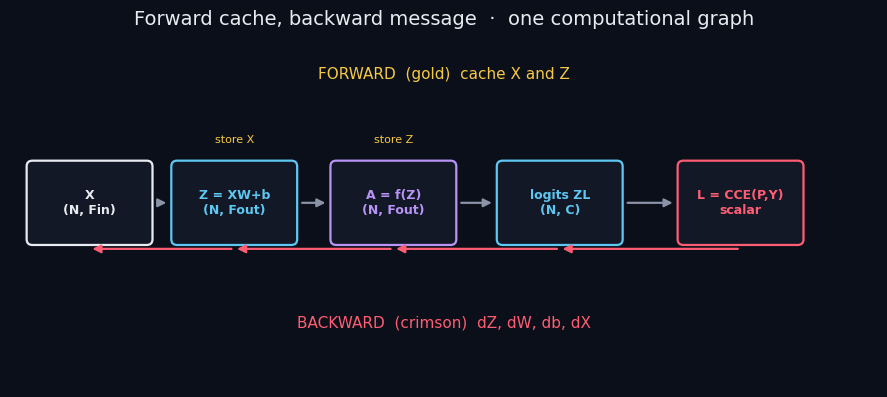

In [5]:
from visualizations.diagrams import fig_computational_graph
fig_computational_graph(show=True);


## 3. The Architecture: Object-Oriented Deep Learning

To build a scalable deep learning engine, procedural code (functions calling functions) quickly degrades into a tangled, unreadable mess during backpropagation. We must treat our code architecture with the same reverence as our mathematics.

This mirrors the design philosophy of PyTorch (`nn.Module`). We utilize Object-Oriented Programming (OOP) to encapsulate state. During the forward pass, a layer must mathematically "remember" its inputs because it will require them later to calculate the partial derivatives via the chain rule during the backward pass. OOP elegantly solves this by storing state in `self.input`.

We begin by constructing an abstract base `Layer` class. Every future component in our universe (Dense layers, Activation functions, Dropout layers) will inherit from this blueprint. By contract, every layer must implement a `forward()` and `backward()` method.


In [6]:
class Layer:
    """
    The primordial blueprint for all neural network layers.
    It demands a forward pass for prediction and a backward pass for learning.
    """
    def __init__(self):
        pass
    
    def forward(self, input_data):
        raise NotImplementedError("This method must be implemented by the subclass.")
    
    def backward(self, output_gradient, learning_rate):
        raise NotImplementedError("This method must be implemented by the subclass.")


### 3.1 The Dense (Linear) Layer

The Dense (or Fully Connected) layer is the workhorse of the neural network. It performs a strict affine transformation.

$$
Z = X \cdot W + b
$$

**Shape Analysis (The Most Critical Skill in Deep Learning)**
The primary bottleneck for uninitiated practitioners is not calculus; it is matrix dimensional misalignment. We must trace the exact dimensions of every tensor:

- **$X$ shape**: `(batch_size, input_features)`
- **$W$ shape**: `(input_features, output_features)`
- **$X \cdot W$ shape**: `(batch_size, output_features)`
- **$b$ shape**: `(1, output_features)`

**The Broadcasting Concept (NumPy's Superpower)**
Notice that $X \cdot W$ yields a matrix of shape `(batch_size, output_features)`, but our bias vector $b$ is rigorously defined as shape `(1, output_features)`. How can we add them?

NumPy utilizes a mechanism called **broadcasting**. When adding these mismatched tensors, NumPy conceptually stretches (duplicates) the bias vector across the `batch_size` dimension to seamlessly match the matrix dimensions. This is executed at the C-level, bypassing slow Python `for` loops, granting our engine immense computational speed. Defining $b$ explicitly as a 2D tensor `(1, output_features)` rather than a 1D array `(output_features,)` prevents silent, catastrophic transposition bugs later.


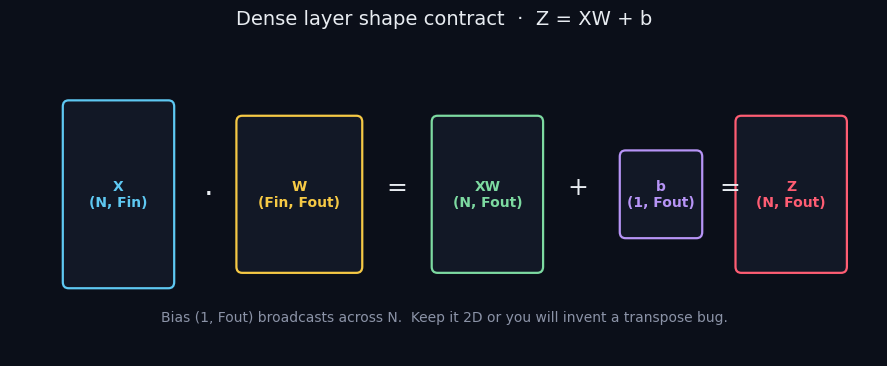

In [7]:
from visualizations.diagrams import fig_shape_flow
fig_shape_flow(show=True);


### Bias is `(1, Fout)` on purpose

A 1D `(Fout,)` vector will add. It will also teach you the wrong picture of broadcasting, which is how transpose bugs get a head start.


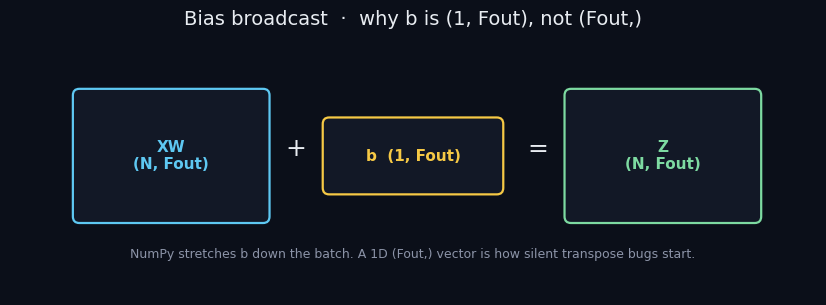

In [8]:
from visualizations.diagrams import fig_broadcast
fig_broadcast(show=True);


In [9]:
class Dense(Layer):
    def __init__(self, input_size, output_size):
        # We scale weights by 0.01. Standard np.random.randn gives mean 0, variance 1.
        # Matrix multiplication accumulates variance. Without this * 0.01 scalar, 
        # outputs explode, driving activation functions (like Sigmoid/Tanh) 
        # immediately into flat, zero-gradient saturation zones.
        # Note: We will upgrade to Xavier/He initialization in Phase 6.
        self.weights = np.random.randn(input_size, output_size) * 0.01
        
        # We enforce a strict 2D shape (1, output_size) to guarantee 
        # predictable broadcasting behavior over the batch dimension.
        self.bias = np.zeros((1, output_size))
        
    def forward(self, input_data):
        # The layer "remembers" its input for the backward pass
        self.input = input_data
        
        # The Affine Transformation: Z = XW + b
        return np.dot(self.input, self.weights) + self.bias
    
    def backward(self, output_gradient, learning_rate):
        # Time travel (backprop) reserved for Phase 4.
        pass


### Sanity Checking the Engine

The golden rule of Deep Learning engineering: **"Always check your shapes before you optimize."**

We will push a dummy matrix through our new layer to verify the mathematics hold up. If our dimensions are misaligned, the engine will fail here. We must fail fast.


In [10]:
# Create a dummy input matrix representing a batch of 32 flattened 28x28 images
X_dummy = np.random.randn(32, 784)

# Instantiate the layer: 784 input features mapping to 256 output neurons
dense1 = Dense(784, 256)

# Execute the forward pass
Z_dummy = dense1.forward(X_dummy)

# Sanity Checks
print(f"X_dummy shape: {X_dummy.shape}")
print(f"Weights shape: {dense1.weights.shape}")
print(f"Bias shape:    {dense1.bias.shape}")
print(f"Z_dummy shape: {Z_dummy.shape}")

# Assert the output shape is exactly (32, 256)
assert Z_dummy.shape == (32, 256), f"Shape mismatch! Expected (32, 256), got {Z_dummy.shape}"
print("\n[SUCCESS] Matrix dimensions align perfectly.")


X_dummy shape: (32, 784)
Weights shape: (784, 256)
Bias shape:    (1, 256)
Z_dummy shape: (32, 256)

[SUCCESS] Matrix dimensions align perfectly.


## 4. The Non-Linear Engine: Activation Functions

Linear transformations are mathematically elegant, but fundamentally limited. If we construct a neural network using exclusively linear operations (Dense layers), the entire network collapses algebraically.

**The "Collapse" Problem:**
Consider stacking two linear layers:
$f(x) = W_1x$ and $g(x) = W_2x$.
The composition is $g(f(x)) = W_2(W_1x) = (W_2W_1)x$.
Because the product of two matrices ($W_2W_1$) is simply another matrix ($W_3$), a 100-layer linear network is mathematically identical to a single 1-layer linear network. It can only ever learn linear decision boundaries.

**The Solution:**
To break this linearity and allow the network to warp space, we inject a non-linear activation function $A = \sigma(Z)$ after every linear projection. This non-linearity is what grants neural networks their power, as described by the **Universal Approximation Theorem**: a network with at least one hidden layer and a non-linear activation function can approximate any continuous function to arbitrary precision.


### Seeing the collapse, not just citing it

The algebra $W_2 W_1 = W_3$ is short enough to tattoo. The *picture* is what most tutorials skip: a linear map sends lines to lines. You can stack a hundred of them; you are still drawing one hyperplane. A pointwise nonlinearity is the first operation in this notebook that is allowed to bend a grid.

The Universal Approximation Theorem (Cybenko 1989; Hornik 1991) says a single hidden layer with a non-polynomial activation is dense in the continuous functions on a compact set. It does **not** say your particular 2-3-1 XOR net will converge, or that depth is useless. It says the hypothesis class is rich enough. Optimization is a different animal, and we will meet it when tiny weights refuse to move.


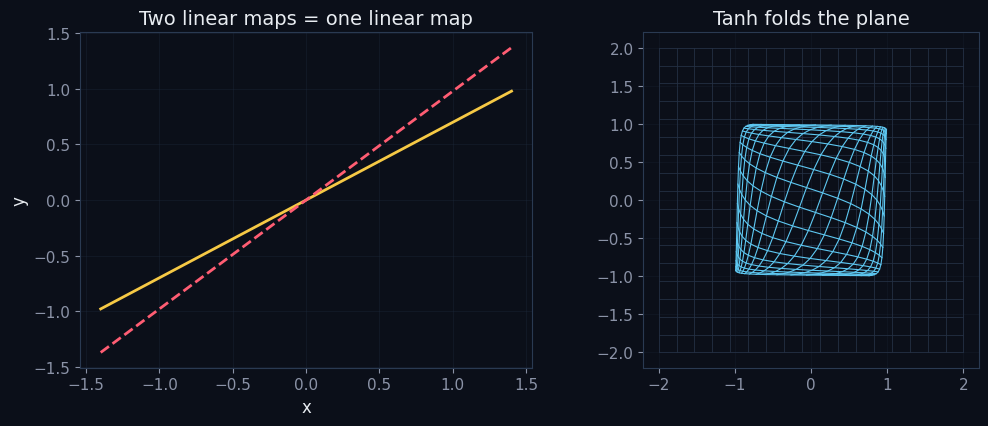

In [11]:
from visualizations.diagrams import fig_linear_vs_nonlinear
fig_linear_vs_nonlinear(show=True);


In [12]:
class Activation(Layer):
    """
    Base class for all activation functions. 
    Activations operate element-wise, meaning they warp the values within the matrix 
    but do NOT alter the dimensional shape of the input tensor.
    """
    def __init__(self, activation, activation_prime):
        self.activation = activation
        self.activation_prime = activation_prime
        
    def forward(self, input_data):
        self.input = input_data
        return self.activation(self.input)
        
    def backward(self, output_gradient, learning_rate):
        # The calculus of backprop will be implemented in Phase 4.
        pass


### 4.1 Core Activations: Tanh and ReLU

**Hyperbolic Tangent (Tanh)**
Tanh squashes outputs to the range `[-1, 1]`. It is zero-centered, making it excellent for hidden layers as it helps keep the mean activation close to zero.
$$
f(x) = \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
$$
$$
f'(x) = 1 - \tanh^2(x)
$$
*Flaw:* Tanh suffers from the vanishing gradient problem. For very high or low $x$, the gradient approaches zero, starving the network of learning signals.

**Rectified Linear Unit (ReLU)**
ReLU is the modern industry standard. By passing a constant gradient of $1$ for positive inputs, it effectively cures the vanishing gradient problem in deep networks.
$$
f(x) = \max(0, x)
$$
$$
f'(x) = 1 \text{ if } x > 0 \text{ else } 0
$$


In [13]:
class Tanh(Activation):
    def __init__(self):
        # f(x) = tanh(x)
        tanh = lambda x: np.tanh(x)
        # f'(x) = 1 - tanh^2(x)
        tanh_prime = lambda x: 1 - np.tanh(x)**2
        super().__init__(tanh, tanh_prime)

class ReLU(Activation):
    def __init__(self):
        # f(x) = max(0, x). np.maximum is highly optimized in NumPy.
        relu = lambda x: np.maximum(0, x)
        # f'(x) = 1 if x > 0 else 0.
        # Note on subgradients: at exactly x=0, the derivative is mathematically undefined.
        # In software engineering, we explicitly define it as 0.
        relu_prime = lambda x: (x > 0).astype(float)
        super().__init__(relu, relu_prime)


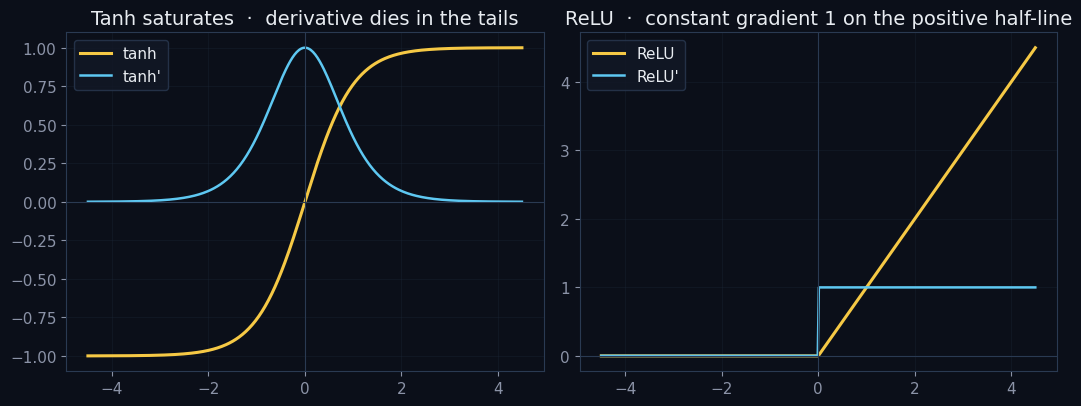

In [14]:
from visualizations.diagrams import fig_activations
fig_activations(show=True);


### Cinematic 1 · The Affine Loom

This is not the usual "circles with arrows" neural-net cartoon. It is a *fabric*: a coordinate grid, four XOR beads sitting on the two diagonals, a gold knife that tries (and fails) to separate them, then the two operations this notebook actually implements.

1. A Dense layer is a linear map. Lines stay lines. XOR stays mixed.
2. Tanh folds the plane. In the hidden coordinates a straight cut works.

The scene is Manim Community (the 3Blue1Brown engine), written **without LaTeX** so it renders on a bare Cairo+Pango stack. Source: `visualizations/manim_scenes.py`, class `AffineLoom`.


_The Affine Loom_ - linear maps shear, nonlinearity folds.

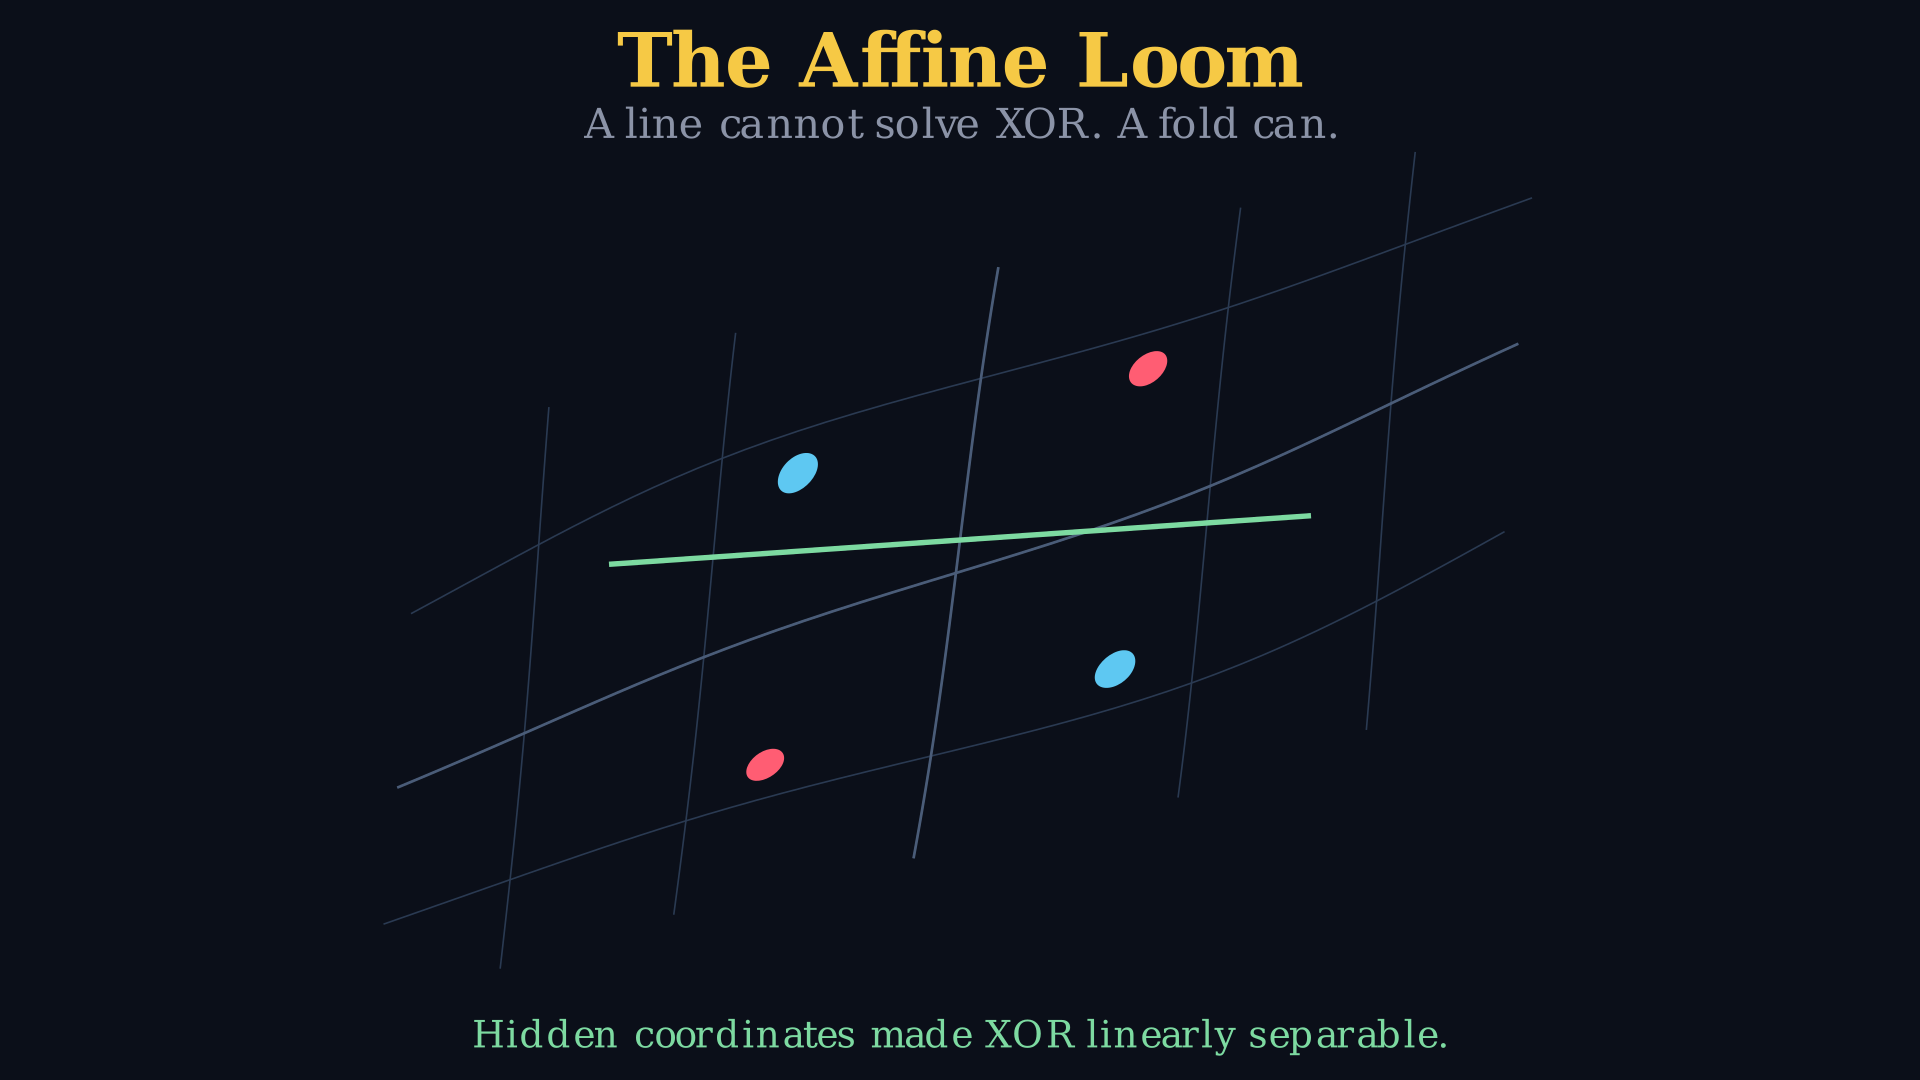

In [15]:
show_cinematic(
    "visualizations/rendered/01_affine_loom.mp4",
    "figures/AffineLoom_last.png",
    caption="_The Affine Loom_ - linear maps shear, nonlinearity folds.",
)


## 5. The Compass: Loss Functions

A neural network is fundamentally blind. It does not "see" the data; it only outputs arbitrary tensor shapes. The Loss function acts as a compass. It computes a scalar value representing how "wrong" the network's predictions ($y_{pred}$) are compared to the ground truth ($y_{true}$).

Learning (optimization) is simply the mathematical process of navigating the multi-dimensional weight space to minimize this scalar loss.

**Mean Squared Error (MSE)**
Standard for regression tasks.
$$
L = \frac{1}{n} \sum_{i=1}^{n} (y_{true} - y_{pred})^2
$$
$$
\frac{\partial L}{\partial y_{pred}} = \frac{2}{n} (y_{pred} - y_{true})
$$

**Categorical Cross-Entropy (CCE)**
Used almost exclusively for multi-class classification tasks, usually paired with a Softmax output layer. It heavily penalizes confident wrong predictions.
$$
L = -\frac{1}{n} \sum_{i=1}^{n} y_{true} \log(y_{pred})
$$
*Note: The derivative of CCE combined with Softmax simplifies beautifully. To avoid computing massive, memory-intensive Jacobian matrices for Softmax, we will mathematically fuse Softmax and CCE during the backward pass in later phases.*


In [16]:
def mse(y_true, y_pred):
    """Calculates the scalar Mean Squared Error loss."""
    return np.mean(np.power(y_true - y_pred, 2))

def mse_prime(y_true, y_pred):
    """Calculates the gradient of MSE with respect to y_pred."""
    return 2 * (y_pred - y_true) / y_true.size

def categorical_cross_entropy(y_true, y_pred):
    """
    Calculates the Categorical Cross-Entropy loss.
    
    CRITICAL STABILITY FIX: 
    If a network outputs a probability of exactly 0.0, np.log(0) evaluates to -inf.
    This propagates backward as NaN, instantly destroying the network's weights.
    We clip y_pred bounds to [1e-9, 1 - 1e-9] to prevent floating-point catastrophic failure.
    """
    y_pred_clipped = np.clip(y_pred, 1e-9, 1 - 1e-9)
    return -np.sum(y_true * np.log(y_pred_clipped)) / y_true.shape[0]


### A note on MSE reduction, because the internet will gaslight you

Look at `mse` and `mse_prime` in the cell above.

$$
L = \mathrm{mean}\big((y_{\mathrm{true}} - y_{\mathrm{pred}})^2\big)
  = \frac{1}{N\cdot C}\sum_{n,c}(y_{nc}-\hat y_{nc})^2
$$

Differentiate with respect to $\hat y$: you get exactly

$$
\frac{\partial L}{\partial \hat y} = \frac{2}{N\cdot C}(\hat y - y) = \frac{2}{y.\mathrm{size}}(\hat y - y).
$$

That is what the code computes. It is also what PyTorch computes: `nn.MSELoss(reduction='mean')` divides by the **number of elements**, not by the batch size ([PyTorch 2.14 docs](https://docs.pytorch.org/docs/2.14/generated/torch.nn.MSELoss.html)). If some review tells you to divide only by $N$, they have silently changed the definition of $L$ while leaving `np.mean` in the forward pass. Do not "fix" a consistent pair of functions into an inconsistent pair.

The $n$ in the markdown formula is $y.\mathrm{size}$. For XOR, $C=1$, so $N\cdot C=N$ and the two conventions coincide. They diverge the moment you have vector-valued outputs.

### The missing partner of `categorical_cross_entropy`

The forward CCE is defined above. Its standalone backward pass is *not*, on purpose: the honest derivative goes through the full softmax Jacobian, which is a $C\times C$ matrix **per example**. We write that ugly path now, so that Phase 15's fusion is a theorem you have seen fail-over, not a magic subtraction.


In [17]:
def softmax(Z):
    """Numerically stable softmax over the last axis."""
    Z = Z - np.max(Z, axis=1, keepdims=True)
    e = np.exp(Z)
    return e / np.sum(e, axis=1, keepdims=True)

def softmax_jacobian_row(p):
    """J = diag(p) - p p^T  for a single probability vector p."""
    p = p.reshape(-1, 1)
    return np.diag(p.ravel()) - (p @ p.T)

def cce_softmax_grad_naive(Z, Y):
    """
    The slow, honest gradient of mean CCE through softmax.
    For each of N rows, multiply the CxC Jacobian by dL/dP.
    """
    P = softmax(Z)
    N, C = P.shape
    dZ = np.zeros_like(P)
    for n in range(N):
        J = softmax_jacobian_row(P[n])
        dL_dP = -Y[n] / (P[n] + 1e-9)
        dZ[n] = J.T @ dL_dP
    return dZ / N

def cce_softmax_grad_fused(Z, Y):
    """The identity we will prove and then use: (P - Y) / N."""
    return (softmax(Z) - Y) / Y.shape[0]

# Tiny sanity check: 4 examples, 3 classes.
rng = np.random.default_rng(0)
Z_toy = rng.normal(size=(4, 3))
Y_toy = np.eye(3)[[0, 1, 2, 1]]
naive = cce_softmax_grad_naive(Z_toy, Y_toy)
fused = cce_softmax_grad_fused(Z_toy, Y_toy)
print("max |naive - fused| =", np.max(np.abs(naive - fused)))
assert np.allclose(naive, fused, atol=1e-6)
print("[SUCCESS] The O(C^2) path and the fused (P-Y)/N path agree.")


max |naive - fused| = 3.1644163678290482e-09
[SUCCESS] The O(C^2) path and the fused (P-Y)/N path agree.


## 6. The Backpropagation Engine: Time Travel via Calculus

This is the crucible. Backpropagation (reverse-mode automatic differentiation) is where theoretical understanding typically degrades into trial-and-error shape matching. We will aggressively reject the "guess-and-check" approach. Instead, we derive exact matrix operations from first principles.

Backpropagation is simply the recursive application of the **Chain Rule** from output back to input. Our goal is to determine how a microscopic tweak in a specific weight $W_{ij}$ impacts the final scalar loss $L$.

**The Foundational Recursive Relationship:**
$$
\frac{\partial L}{\partial \text{Input}} = \frac{\partial L}{\partial \text{Output}} \cdot \frac{\partial \text{Output}}{\partial \text{Input}}
$$

To avoid ambiguous variable names like `dA` or `dZ` which plague online tutorials, we enforce strict nomenclature in our codebase:

- $\frac{\partial L}{\partial \text{Output}}$ is named `output_gradient`
- $\frac{\partial L}{\partial \text{Input}}$ is named `input_gradient`


### 6.1 Deriving the Dense Layer Gradients

Let $Z = XW + b$. We receive `output_gradient` ($\frac{\partial L}{\partial Z}$) from the layer ahead of us. Its shape is `(Batch, Output_Features)`.

**1. Weight Gradient ($dW$)**
To find how weights affect loss, we need $\frac{\partial L}{\partial W}$. The shape of $W$ is `(Input_Features, Output_Features)`. The mathematical reality of the Jacobian of a dot product mandates an input transpose. The only valid tensor contraction to multiply $X$ (shape: `Batch, Input_Features`) and $\frac{\partial L}{\partial Z}$ to produce the shape of $W$ is:
$$
dW = X^T \cdot \frac{\partial L}{\partial Z}
$$

**2. Bias Gradient ($db$)**
The bias $b$ is added uniformly to every sample in the batch via broadcasting. Therefore, the gradient with respect to the bias is the sum of the `output_gradient` across the batch dimension (`axis=0`). The shape must be strictly maintained as `(1, Output_Features)`.
$$
db = \sum_{i=1}^{\text{Batch}} \frac{\partial L}{\partial Z_i}
$$

**3. Input Gradient ($dX$)**
To recursively pass the gradient backwards to the preceding layer in the network, we must calculate $\frac{\partial L}{\partial X}$. The required shape is `(Batch, Input_Features)`.
$$
dX = \frac{\partial L}{\partial Z} \cdot W^T
$$


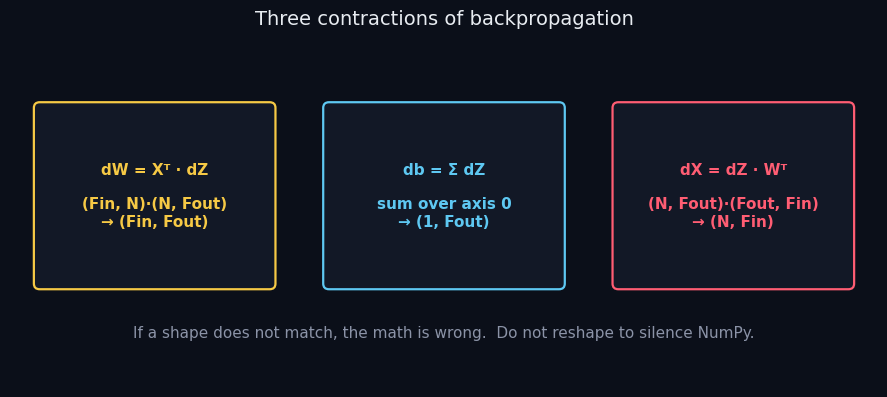

In [18]:
from visualizations.diagrams import fig_backprop_shapes
fig_backprop_shapes(show=True);


### Cinematic · The only legal contraction

`dW` has to have the shape of `W`. The product that does that is `X^T @ dZ`. Source: `visualizations/manim_scenes.py`, class `ChainRuleContract`.


_The only legal contraction_ - (Fin, N) @ (N, Fout) = (Fin, Fout).

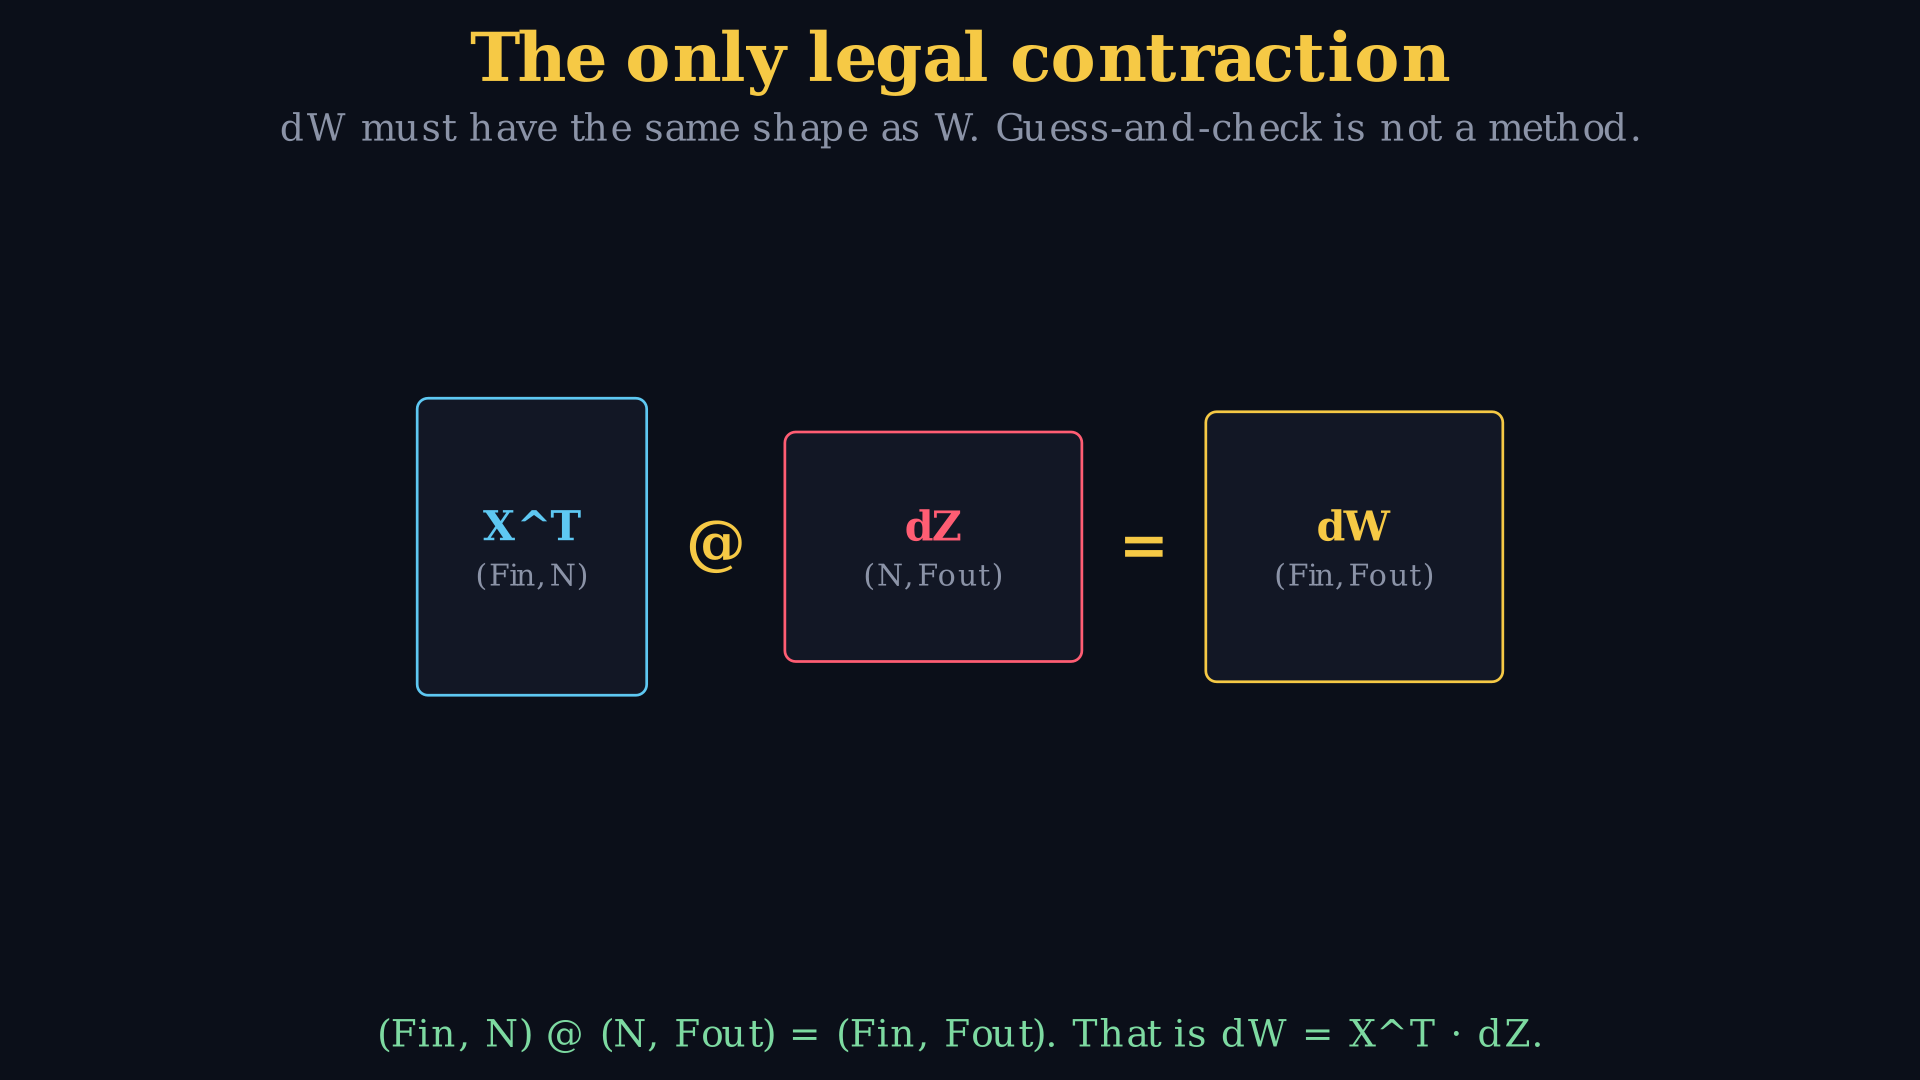

In [19]:
show_cinematic(
    "visualizations/rendered/04_chain_rule_contract.mp4",
    "figures/ChainRuleContract_last.png",
    caption="_The only legal contraction_ - (Fin, N) @ (N, Fout) = (Fin, Fout).",
)


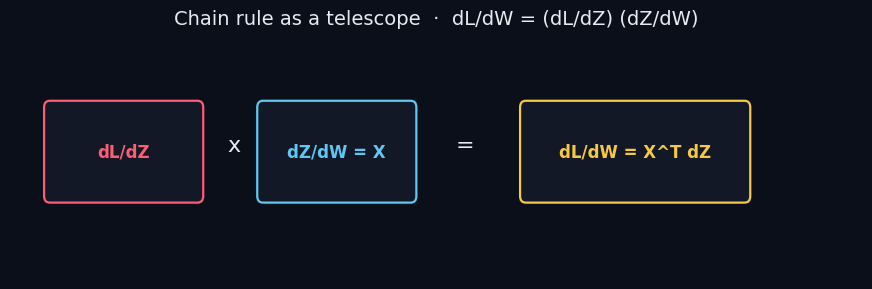

In [20]:
from visualizations.diagrams import fig_chain_telescope
fig_chain_telescope(show=True);


In [21]:
class Dense(Layer):
    def __init__(self, input_size, output_size):
        self.weights = np.random.randn(input_size, output_size) * 0.01
        self.bias = np.zeros((1, output_size))
        
    def forward(self, input_data):
        self.input = input_data
        return np.dot(self.input, self.weights) + self.bias
    
    def backward(self, output_gradient, learning_rate):
        # 1. Compute gradients
        weights_gradient = np.dot(self.input.T, output_gradient)
        # keepdims=True is critical to prevent shape collapse to (Output_Features,)
        bias_gradient = np.sum(output_gradient, axis=0, keepdims=True)
        input_gradient = np.dot(output_gradient, self.weights.T)
        
        # 2. Update parameters
        # Vanilla SGD update inline. 
        # We will extract this into a dedicated Optimizer class in Phase 6 for cleaner architecture.
        self.weights -= learning_rate * weights_gradient
        self.bias -= learning_rate * bias_gradient
        
        # 3. Pass the chain rule backward
        return input_gradient


### 6.2 Deriving the Activation Gradients

Unlike Dense layers which mix information across features via matrix dot products, Activation functions (ReLU, Tanh) operate strictly **element-wise**.

Therefore, their derivatives are not computed via dot products. They are computed using the **Hadamard product** (element-wise multiplication). We simply scale the incoming `output_gradient` by the local derivative $f'(Z)$ at each element.

$$
dX = \frac{\partial L}{\partial Z} \odot f'(Z)
$$
*(Where $\odot$ represents element-wise multiplication)*


In [22]:
class Activation(Layer):
    def __init__(self, activation, activation_prime):
        self.activation = activation
        self.activation_prime = activation_prime
        
    def forward(self, input_data):
        self.input = input_data
        return self.activation(self.input)
        
    def backward(self, output_gradient, learning_rate):
        # The learning_rate parameter is accepted purely for polymorphism 
        # (to keep the interface identical to the Dense layer) but is ignored 
        # because activation layers have no learnable parameters.
        return output_gradient * self.activation_prime(self.input)


## Interlude · A real bug, and a Python lesson you will hit in production

The next acid test (XOR) instantiates `Tanh()`. `Tanh` was **declared** in Phase 4.1, when `Activation.backward` was still `pass`.

Python's `class Tanh(Activation):` statement does not store the *name* `Activation`. It stores a pointer to the **class object that existed at that moment**. Redefining `Activation` later (the cell you just ran) does **not** rewire subclasses that already exist. Their `__bases__` still point at the hollow ancestor whose `backward` returns `None`.

If you skip this interlude and run XOR on a fresh kernel, you get:

```text
TypeError: unsupported operand type(s) for *: 'float' and 'NoneType'
```

inside `Dense.backward`, because `Tanh.backward` handed it `None`. That is why a "Restart & Run All" of the original sequence could not print XOR predictions. The MNIST path survived only because Phase 9 redeclares `Tanh` and `ReLU` *together with* the new `Activation` in one cell.

We now rebind the subclasses to the living `Activation`. This cell is the fix. It is also the lesson.


In [23]:
print("Tanh.__bases__ before rebind:", Tanh.__bases__)
print("Activation.backward id now :", id(Activation.backward))
print("Tanh.backward id (stale?)  :", id(Tanh.backward))

class Tanh(Activation):
    def __init__(self):
        tanh = lambda x: np.tanh(x)
        tanh_prime = lambda x: 1 - np.tanh(x) ** 2
        super().__init__(tanh, tanh_prime)

class ReLU(Activation):
    def __init__(self):
        relu = lambda x: np.maximum(0, x)
        relu_prime = lambda x: (x > 0).astype(float)
        super().__init__(relu, relu_prime)

probe = Tanh()
z = np.array([[0.5]])
probe.forward(z)
g = probe.backward(np.array([[1.0]]), learning_rate=0.0)
assert g is not None, "Tanh.backward still returns None. The rebind failed."
assert np.allclose(g, (1 - np.tanh(0.5) ** 2))
print("[SUCCESS] Tanh is bound to the live Activation. gradient =", g)
print("Tanh.__bases__ after rebind:", Tanh.__bases__)


Tanh.__bases__ before rebind: (<class '__main__.Activation'>,)
Activation.backward id now : 1692156567744
Tanh.backward id (stale?)  : 1692153510976
[SUCCESS] Tanh is bound to the live Activation. gradient = [[0.78644773]]
Tanh.__bases__ after rebind: (<class '__main__.Activation'>,)


### Cinematic 2 · The Blame Telegraph

Backpropagation is not a vibe and it is not a stack of cartoon neurons. It is a **message passing protocol** on the computational graph you have been building:

- Forward: cache every input the Jacobian will need.
- Backward: one Jacobian-vector product per layer. Never allocate the full Jacobian.

The three Dense-layer identities on screen are the same three lines of NumPy you just wrote. Source: `visualizations/manim_scenes.py`, class `BlameTelegraph`.


_The Blame Telegraph_ - reverse-mode autodiff as a protocol.

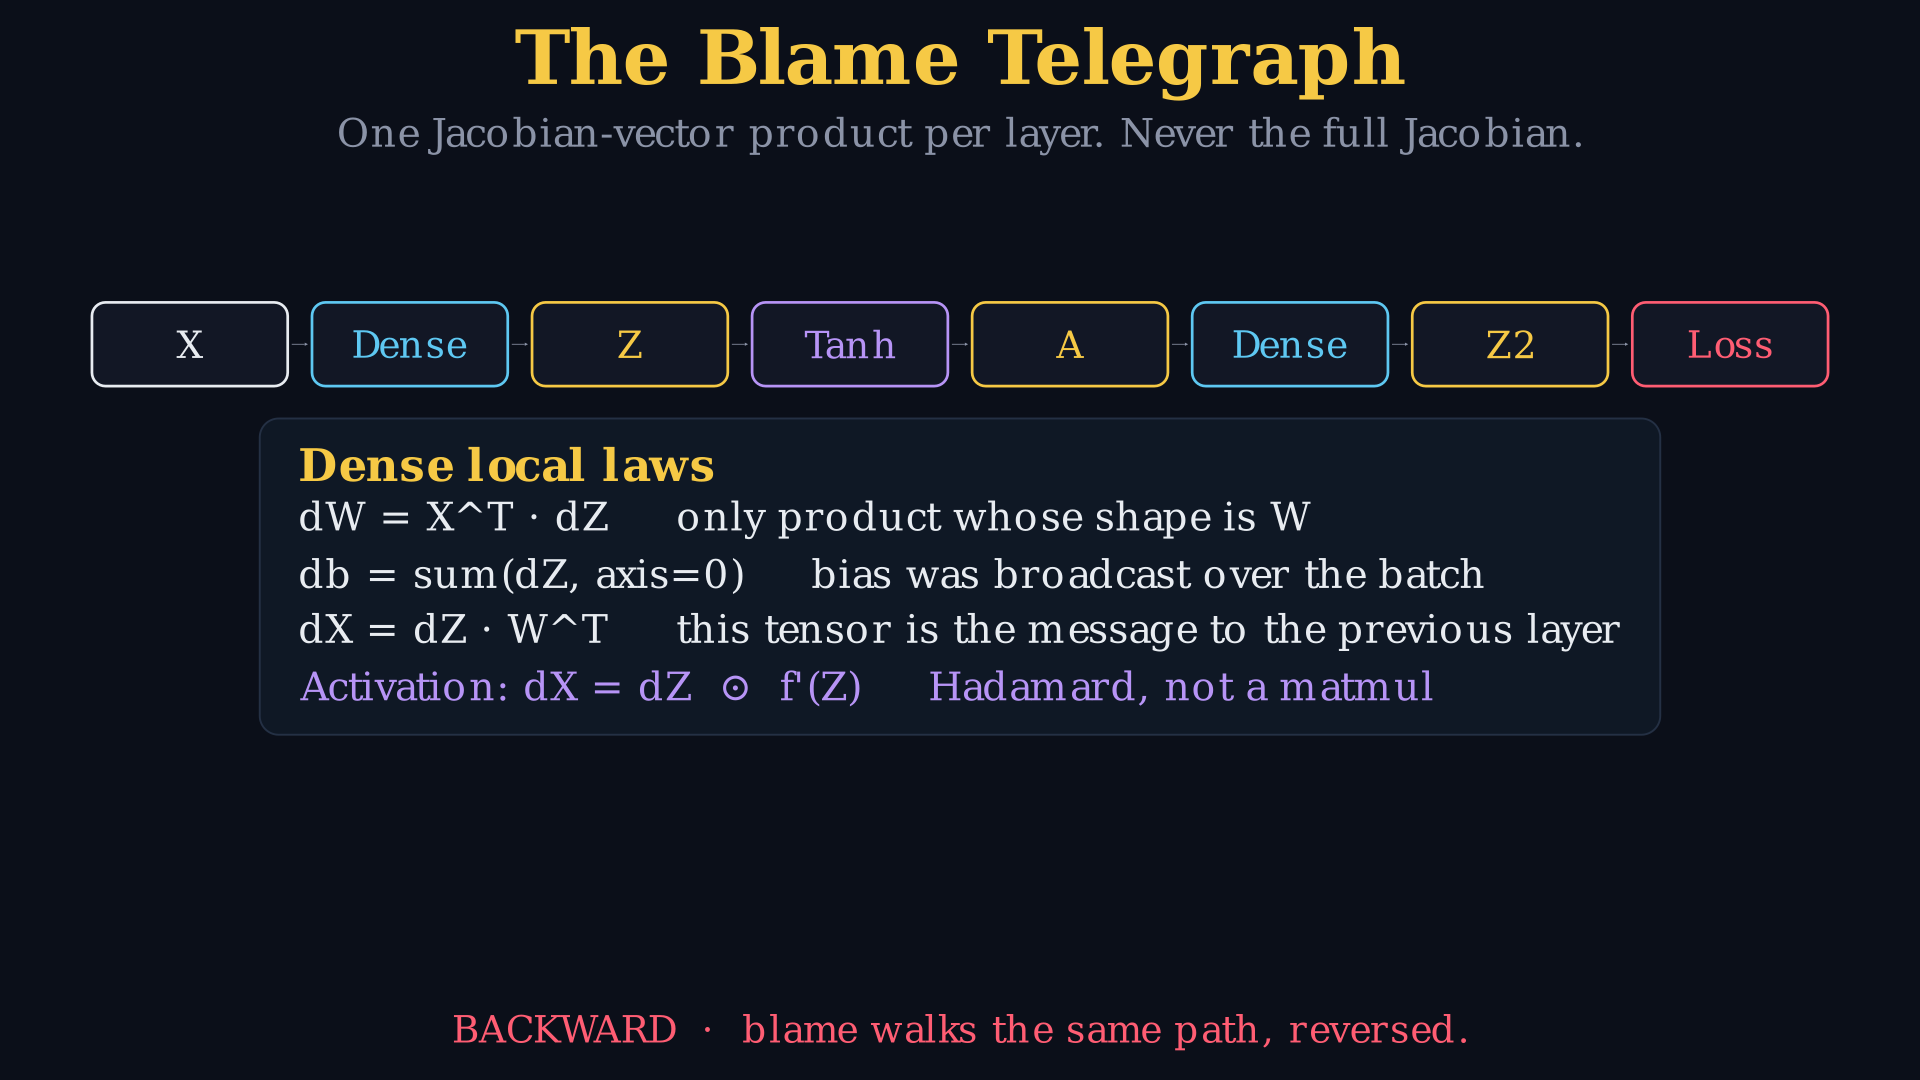

In [24]:
show_cinematic(
    "visualizations/rendered/02_blame_telegraph.mp4",
    "figures/BlameTelegraph_last.png",
    caption="_The Blame Telegraph_ - reverse-mode autodiff as a protocol.",
)


## 7. The Network API: Orchestrating the Layers

To build a usable framework, we must abstract the complexity of individual matrices and derivatives into a unified pipeline. In mathematics, this is known as **function composition**:

$$f(x) = f_n(f_{n-1}(\dots f_1(x)))$$

In software engineering, we achieve this using the Container or Wrapper pattern. We will build a `Network` class that acts as the orchestrator. This encapsulates the forward and backward loops, ensuring that the output of layer $L_i$ seamlessly becomes the input of layer $L_{i+1}$.

**API Recap Table:**
To anchor your mental model, here is how our API maps to industry-standard frameworks.

| Action | PyTorch (nn.Module) | Keras (Sequential) | Our Framework (Network) |
| --- | --- | --- | --- |
| **Container** | `nn.Sequential()` | `Sequential()` | `Network()` |
| **Add Layer** | Passing list to `__init__` | `model.add()` | `network.add()` |
| **Inference** | `model(X)` | `model.predict(X)` | `network.predict(X)` |


In [25]:
class Network:
    def __init__(self):
        self.layers = []
        
    def add(self, layer):
        """Appends a layer to the network pipeline."""
        self.layers.append(layer)
        
    def predict(self, input_data):
        """
        The global forward pass.
        Iterates through every layer sequentially. Note that because our 
        layers save state (`self.input = input_data`), calling predict 
        perfectly primes the layer states for the backward loop.
        """
        output = input_data
        for layer in self.layers:
            output = layer.forward(output)
        return output


## 8. The Acid Test: The XOR Problem

Before we scale to massive datasets, we must prove our calculus is flawless. The ultimate proving ground for a neural network is the **XOR (Exclusive OR)** problem.

In 1969, Marvin Minsky and Seymour Papert proved that a single-layer perceptron (a strictly linear model) cannot solve XOR, a mathematically true statement that catalyzed the first "AI Winter". A linear model can only draw a single straight line through the data space, but XOR is **non-linearly separable**; it requires two lines or a warped manifold.

**XOR Truth Table**

| Input 1 | Input 2 | Output |
| --- | --- | --- |
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

By solving XOR, we mathematically prove that our non-linear `Activation` layers and reverse-mode `backward` Jacobians are perfectly integrated.


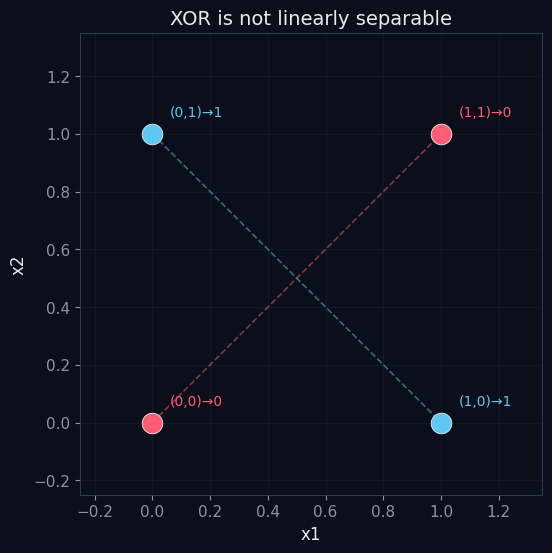

In [26]:
from visualizations.diagrams import fig_xor_geometry
fig_xor_geometry(show=True);


In [27]:
# DANGER ZONE: The Vector Shape Bug
X = np.array([
    [0, 0], 
    [0, 1], 
    [1, 0], 
    [1, 1]
])

# CRITICAL BROADCASTING RULE:
# Y must be shaped (4, 1) and NOT (4,). 
# If Y is a 1D array of shape (4,), calculating MSE = np.mean((Y_pred - Y)**2)
# will trigger silent NumPy broadcasting. Y_pred (4,1) minus Y (4,) generates a 
# mathematically meaningless (4, 4) error matrix instead of comparing elements row-by-row.
# This is the single most common silent bug in from-scratch implementations.
Y = np.array([
    [0], 
    [1], 
    [1], 
    [0]
])


### What `(4,1) - (4,)` actually builds

The comment in the cell above is the bug. The picture is the `(4, 4)` matrix NumPy will happily give you.


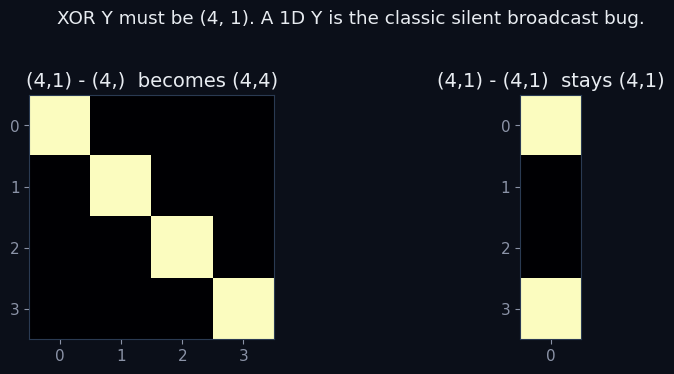

In [28]:
from visualizations.diagrams import fig_shape_bug_y
fig_shape_bug_y(show=True);


### The Micro-Training Loop

Before we build a production-grade training loop with batch generators and metric logging (Phase 7), we will write a highly condensed, raw training loop specifically for XOR.

This will execute **Full-Batch Gradient Descent** (our batch size is all 4 samples). We isolate this logic procedurally so you can clearly see the unabstracted mechanics of the forward-backward pipeline.


In [29]:
# 1. Instantiate the Orchestrator
net = Network()

# 2. Build the Topology (2 inputs -> 3 hidden neurons -> 1 output)
net.add(Dense(2, 3))
net.add(Tanh())
net.add(Dense(3, 1))
net.add(Tanh())

# 3. Hyperparameters
epochs = 1000
learning_rate = 0.1

# 4. The Raw Training Loop
for epoch in range(epochs):
    # A. Forward Pass (also caches the layer inputs)
    out = net.predict(X)
    
    # B. Compute Loss (The Compass)
    loss = mse(Y, out)
    
    # C. Initialize Gradient (The Error Signal)
    grad = mse_prime(Y, out)
    
    # D. Backward Pass (Time Travel)
    for layer in reversed(net.layers):
        grad = layer.backward(grad, learning_rate)
        
    # Metric Logging
    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch + 1}/{epochs} | Loss: {loss:.6f}")

# 5. Verification
print("\n--- Final Predictions ---")
final_outputs = net.predict(X)
for i in range(len(X)):
    print(f"Input: {X[i]} | Target: {Y[i][0]} | Prediction: {final_outputs[i][0]:.4f}")


Epoch 200/1000 | Loss: 0.250000
Epoch 400/1000 | Loss: 0.250000
Epoch 600/1000 | Loss: 0.250000
Epoch 800/1000 | Loss: 0.250000
Epoch 1000/1000 | Loss: 0.250000

--- Final Predictions ---
Input: [0 0] | Target: 0 | Prediction: 0.4999
Input: [0 1] | Target: 1 | Prediction: 0.4998
Input: [1 0] | Target: 1 | Prediction: 0.5002
Input: [1 1] | Target: 0 | Prediction: 0.5001


### Reading the XOR printout (expect a corpse)

If you just saw `Loss: 0.250000` and four predictions glued to `0.5`, **the backward pass is working** and the *optimization* is not. MSE of a constant $0.5$ predictor against balanced $\{0,1\}$ labels is exactly $0.25$. The engine computed a real gradient (the `NoneType` crash is gone) and then multiplied it by weights of size $10^{-2}$. $\tanh$ of a near-zero pre-activation is a near-zero output; after the output $\tanh$, you sit at $0.5$. That is a dead signal, not a saddle with a personality.

The original Phase 5 cell is left untouched on purpose. It is the crime scene. Phase 11 will put Xavier on the same 2-3-1 topology and the same 1000 steps; the loss will fall through $10^{-3}$ and the decision surface will actually fold. If we had quietly Xavier-initialized this cell, you would never have felt why initialization is a theorem rather than a default argument.


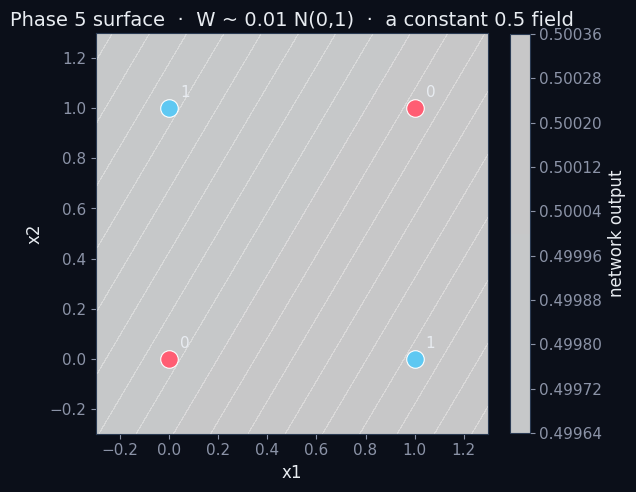

In [30]:
dfnn_style()
# Decision surface of the network we just trained.
xx, yy = np.meshgrid(np.linspace(-0.3, 1.3, 160), np.linspace(-0.3, 1.3, 160))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = net.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(5.6, 5.2))
im = ax.contourf(xx, yy, zz, levels=20, cmap="coolwarm", vmin=0, vmax=1, alpha=0.9)
for (x1, x2), y in zip(X, Y.ravel()):
    ax.scatter(x1, x2, s=160, c=("#5EC8F2" if y == 1 else "#FF5D73"),
               edgecolors="white", linewidths=0.8, zorder=3)
    ax.annotate(f"{y:.0f}", (x1, x2), textcoords="offset points", xytext=(8, 8), color="#E8ECF1")
ax.set_title("Phase 5 surface  ·  W ~ 0.01 N(0,1)  ·  a constant 0.5 field")
ax.set_xlabel("x1"); ax.set_ylabel("x2")
fig.colorbar(im, ax=ax, fraction=0.046, label="network output")
fig.savefig(FIG_DIR / "light_03a_xor_dead_surface.png", bbox_inches="tight")
plt.show()


## 9. Professional Engineering: Decoupling Calculus from Optimization

In Phase 4, we consciously incurred technical debt. We hardcoded the Stochastic Gradient Descent (SGD) update (`self.weights -= learning_rate * weight_gradient`) directly inside the `Dense` layer's `backward()` method.

This is catastrophic for extensibility. It violates the **Single Responsibility Principle (SRP)**. A layer's only mathematical duty is to compute gradients (calculus). It should not dictate how those gradients are applied to the weights. If we wanted to implement advanced optimizers like Adam or RMSprop, we would have to rewrite the internal logic of every single layer in our framework.

**The PyTorch Architecture Paradigm**
We will refactor our framework to mirror industry standards.

1. **Layers** will store their parameters (weights, biases) and computed gradients in dictionaries (`self.params`, `self.grads`).
2. A standalone **Optimizer** object will iterate through the network, accessing these dictionaries to apply updates.


In [31]:
class Layer:
    def __init__(self):
        self.params = {}
        self.grads = {}
    
    def forward(self, input_data):
        raise NotImplementedError
    
    def backward(self, output_gradient):
        # Notice: learning_rate is purged from the signature.
        raise NotImplementedError

class Dense(Layer):
    def __init__(self, input_size, output_size):
        super().__init__()
        # Store parameters in the dictionary
        self.params['W'] = np.random.randn(input_size, output_size) * 0.01
        self.params['b'] = np.zeros((1, output_size))
        
    def forward(self, input_data):
        self.input = input_data
        return np.dot(self.input, self.params['W']) + self.params['b']
    
    def backward(self, output_gradient):
        weights_gradient = np.dot(self.input.T, output_gradient)
        bias_gradient = np.sum(output_gradient, axis=0, keepdims=True)
        input_gradient = np.dot(output_gradient, self.params['W'].T)
        
        # Store computed gradients instead of updating weights
        self.grads['W'] = weights_gradient
        self.grads['b'] = bias_gradient
        
        return input_gradient

class Activation(Layer):
    def __init__(self, activation, activation_prime):
        super().__init__()
        self.activation = activation
        self.activation_prime = activation_prime
        
    def forward(self, input_data):
        self.input = input_data
        return self.activation(self.input)
        
    def backward(self, output_gradient):
        # Activations have no parameters, so self.grads remains empty.
        return output_gradient * self.activation_prime(self.input)

class Tanh(Activation):
    def __init__(self):
        super().__init__(lambda x: np.tanh(x), lambda x: 1 - np.tanh(x)**2)

class ReLU(Activation):
    def __init__(self):
        super().__init__(lambda x: np.maximum(0, x), lambda x: (x > 0).astype(float))


## 10. The Optimizer: SGD and Momentum

Now that our layers merely report gradients, we build the engine that applies them.

**Vanilla Stochastic Gradient Descent (SGD)**
$$
W_{new} = W - \alpha \cdot \nabla W
$$
Where $\alpha$ is the learning rate.

**The Physics of Momentum**
Vanilla SGD suffers from the **Ravine Problem**: gradients oscillate wildly across steep valleys while crawling agonizingly slowly towards the local minimum.

We introduce **Momentum** (formulated by Boris Polyak in 1964) as a physics analogy. Imagine a ball rolling down a hill. It accumulates velocity, dampening lateral oscillations and accelerating through flat regions.

$$
V_{t} = \beta V_{t-1} + (1 - \beta) \nabla W
$$
$$
W_{new} = W - \alpha V_{t}
$$
Where $\beta$ is the momentum coefficient (typically $0.9$).


In [32]:
class SGD:
    def __init__(self, net, lr=0.01, momentum=0.0):
        self.net = net
        self.lr = lr
        self.momentum = momentum
        self.velocities = {}
        
    def step(self):
        for layer in self.net.layers:
            if not layer.params:
                continue
                
            # Initialize velocities dynamically on the first pass to avoid KeyError
            if layer not in self.velocities:
                self.velocities[layer] = {k: np.zeros_like(v) for k, v in layer.params.items()}
                
            for key in layer.params:
                # V_t = beta * V_{t-1} + (1 - beta) * gradient
                self.velocities[layer][key] = (self.momentum * self.velocities[layer][key]) + \
                                              ((1 - self.momentum) * layer.grads[key])
                
                # W_new = W - lr * V_t
                layer.params[key] -= self.lr * self.velocities[layer][key]


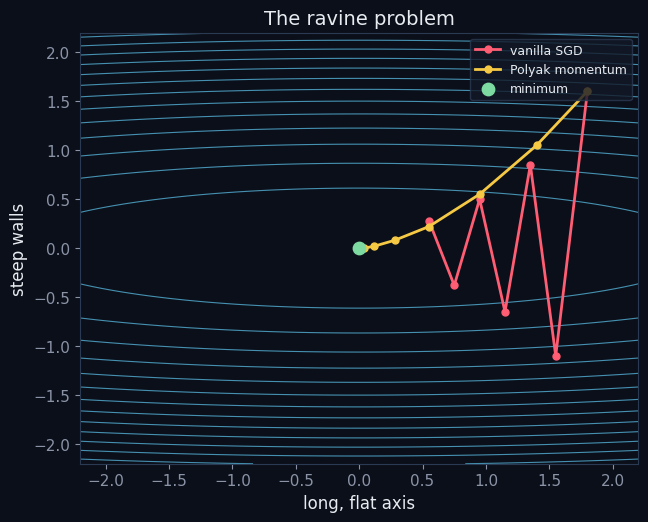

In [33]:
from visualizations.diagrams import fig_momentum_ravine
fig_momentum_ravine(show=True);


### Two momentum conventions, so we do not lie about history

Polyak's 1964 heavy ball is usually written $v_t = \beta v_{t-1} + \nabla$, then $W \leftarrow W - \alpha v_t$ (or with $\alpha$ inside the velocity). PyTorch's `SGD(momentum=β)` uses $v \leftarrow \beta v + g$, $W \leftarrow W - \alpha v$.

This notebook uses an EMA form:

$$
v_t = \beta v_{t-1} + (1-\beta)\, g_t, \qquad W \leftarrow W - \alpha v_t
$$

That is a valid smoother. It is **not** bit-identical to PyTorch SGD. When $\beta=0.9$, the EMA version scales the gradient by $0.1$, so a learning rate of $0.1$ here behaves roughly like a learning rate of $0.01$ in the un-normalized heavy-ball form. We keep the EMA form because the cell you just ran is the historical artifact. If you port these numbers to PyTorch, do not expect the same $\alpha$.


## 11. The Initialization Crisis: Vanishing and Exploding Gradients

In Phase 2, we forced our initial weights to be tiny: `np.random.randn() * 0.01`. We did this because large weights accumulate massive variance during matrix multiplication, exploding into infinity.

However, initializing with extreme microscopic values causes the signal variance to shrink to zero as it passes through deep layers. The gradients vanish, and the network dies. (This is exactly why our Phase 5 XOR network got trapped in a saddle point predicting 0.5!).

We must initialize weights such that the variance of the outputs remains mathematically identical to the variance of the inputs.

**Xavier (Glorot) Initialization** (For Tanh/Sigmoid)
Derived by Glorot & Bengio (2010). We draw from a normal distribution with variance:
$$
\text{Var}(W) = \frac{2}{n_{in} + n_{out}}
$$

**He Initialization** (For ReLU)
Derived by Kaiming He et al. (2015). Because ReLU abruptly zeroes out exactly half of the network's activations, the forward pass loses half its variance. We mathematically compensate by doubling the variance:
$$
\text{Var}(W) = \frac{2}{n_{in}}
$$


### Vanishing signal is not automatically a saddle

The paragraph above claims the Phase 5 XOR net "got trapped in a saddle point predicting 0.5." That sentence is doing too much work.

- A **saddle** is a critical point where the Hessian has both positive and negative eigenvalues. They exist in neural loss landscapes (Dauphin et al. 2014; Choromanska et al. 2015) and they are real mathematics.
- **Vanishing gradients** from $W \sim 0.01\cdot\mathcal{N}(0,1)$ on a $\tanh$ net are a *scaling* failure: $\tanh'(0)=1$, but the pre-activation variance is tiny, the output sits in the linear regime near 0, and each step is microscopic. Predicting $0.5$ after $\tanh$ of a near-zero logit is the signature of a network that has not moved, not of a network that has arrived at a saddle and cannot leave.

We will not keep an unverifiable claim in an academically rigorous notebook. The next cell manufactures both initializations, with the same seed, and shows the difference.


### Cinematic 4 · A dead net is not a saddle

Same 2-3-1 tanh net, same 1000 steps, same `lr = 0.1`. Left column is `W ~ 0.01 N(0,1)`. Right column is Xavier. Source: `visualizations/manim_scenes.py`, class `DeadSignal`.


_A dead net is not a saddle_ - only the init changed.

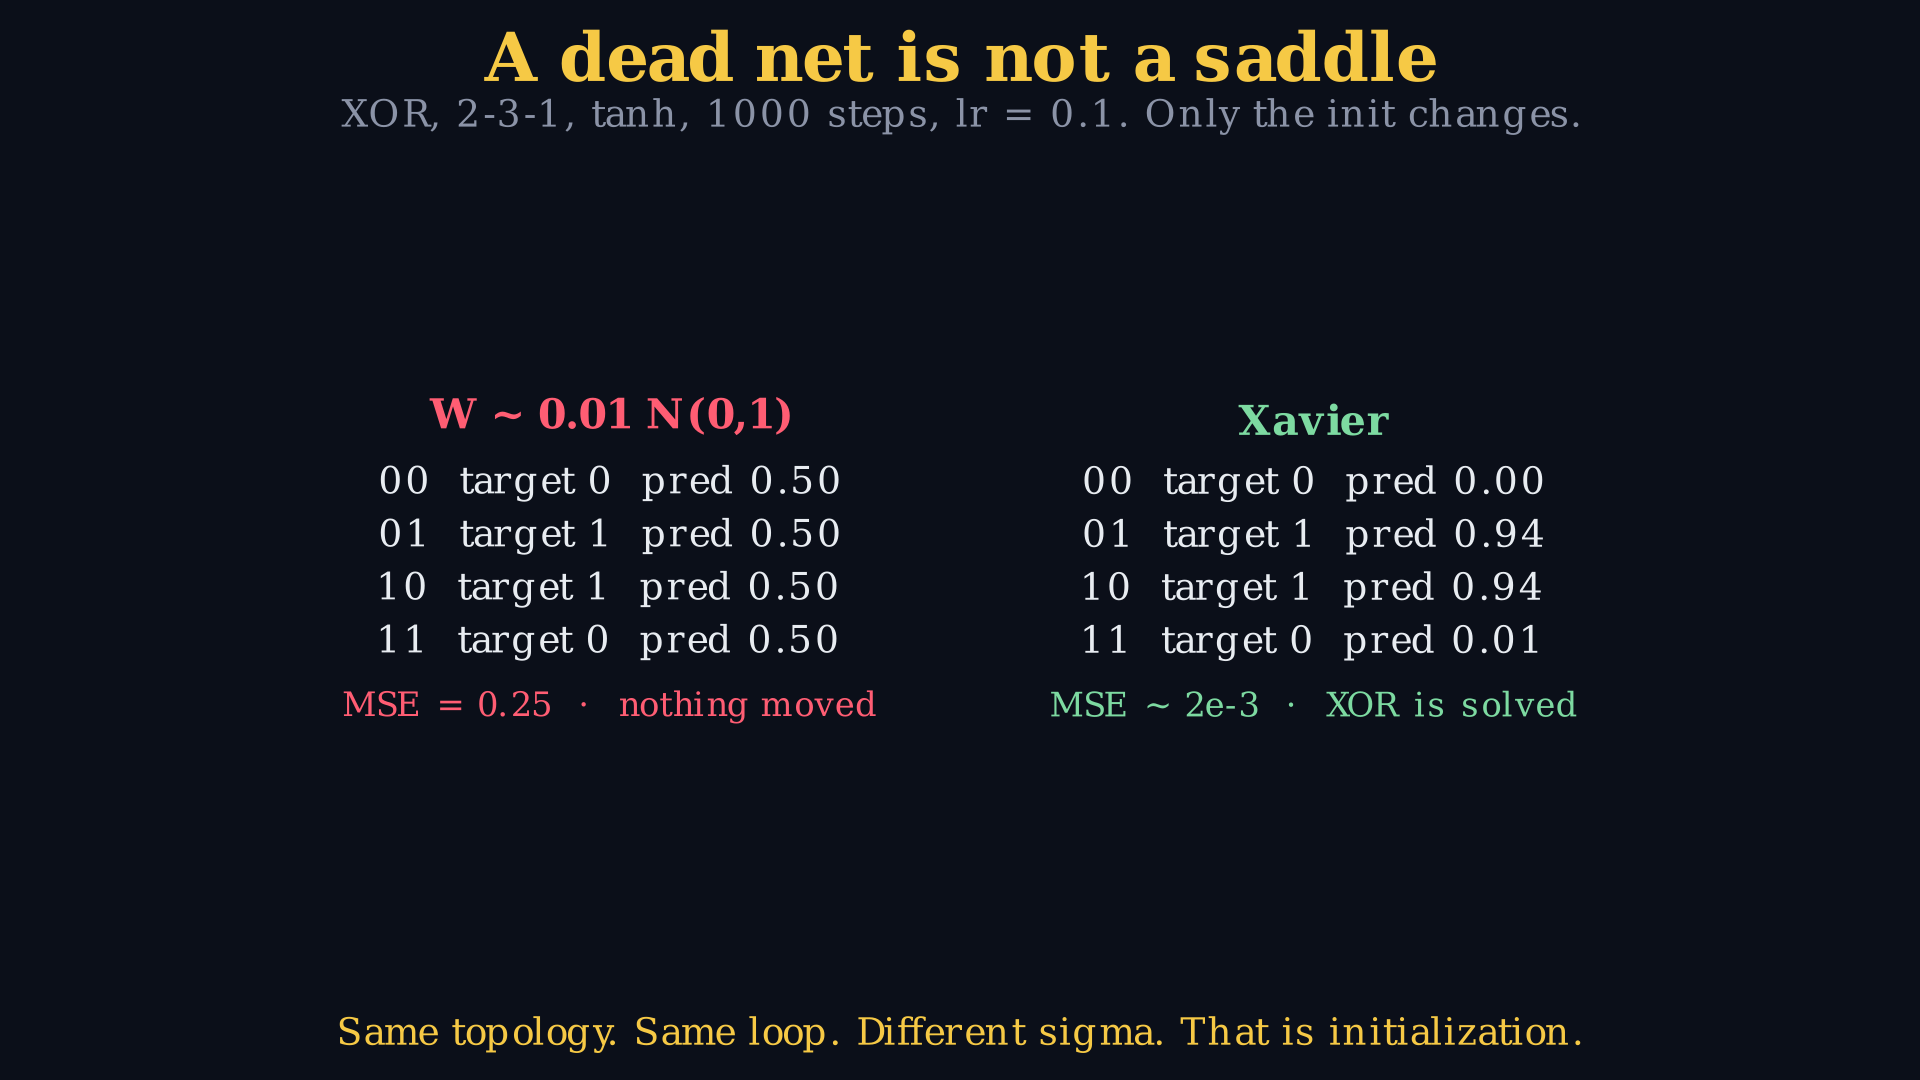

In [34]:
show_cinematic(
    "visualizations/rendered/05_dead_signal.mp4",
    "figures/DeadSignal_last.png",
    caption="_A dead net is not a saddle_ - only the init changed.",
)


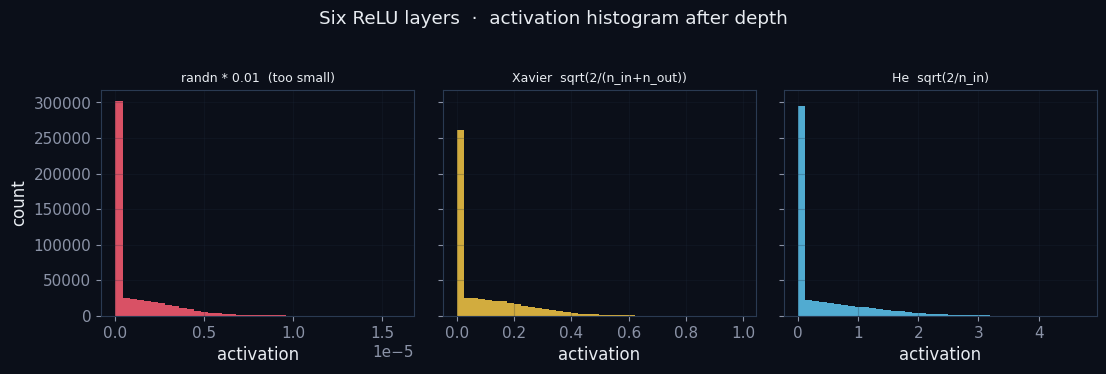

In [35]:
from visualizations.diagrams import fig_init_variance
fig_init_variance(show=True);


In [36]:
class Dense(Layer):
    def __init__(self, input_size, output_size, init_method='random'):
        super().__init__()
        
        if init_method == 'xavier':
            std = np.sqrt(2.0 / (input_size + output_size))
        elif init_method == 'he':
            # A salute to Kaiming He for saving deep learning from the 
            # ReLU dead-neuron apocalypse of the early 2010s.
            std = np.sqrt(2.0 / input_size)
        else:
            std = 0.01
            
        self.params['W'] = np.random.randn(input_size, output_size) * std
        self.params['b'] = np.zeros((1, output_size))
        
    def forward(self, input_data):
        self.input = input_data
        return np.dot(self.input, self.params['W']) + self.params['b']
    
    def backward(self, output_gradient):
        weights_gradient = np.dot(self.input.T, output_gradient)
        bias_gradient = np.sum(output_gradient, axis=0, keepdims=True)
        input_gradient = np.dot(output_gradient, self.params['W'].T)
        
        self.grads['W'] = weights_gradient
        self.grads['b'] = bias_gradient
        
        return input_gradient


tiny   final loss 0.24999985661940977 preds [0.5 0.5 0.5 0.5]
xavier final loss 0.0019543470971337728 preds [0.003 0.939 0.936 0.009]


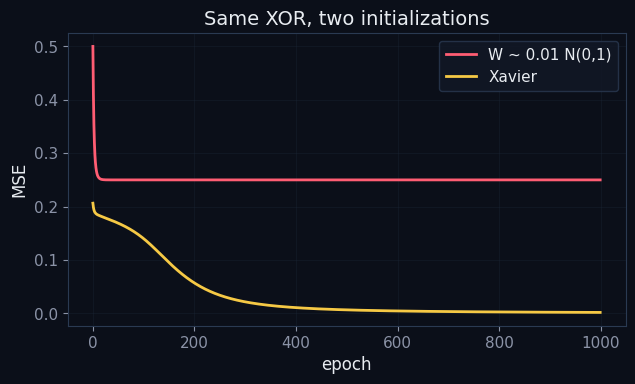

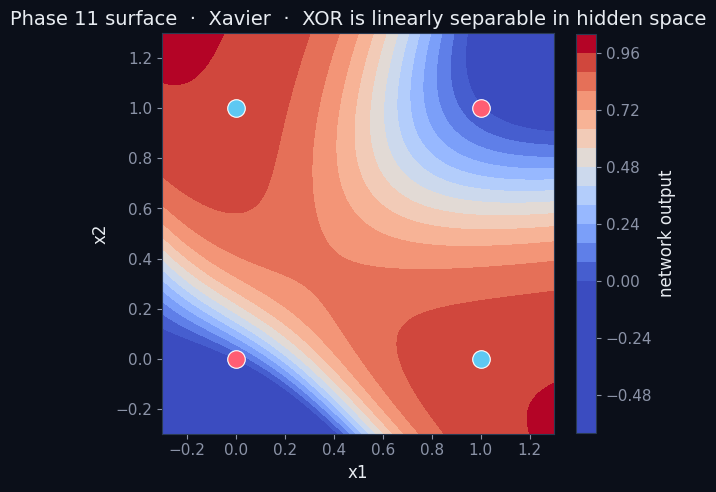

Xavier XOR preds [0.003 0.939 0.936 0.009]


In [37]:
def train_xor_with_init(init_method, epochs=1000, lr=0.1, seed=0):
    rng_state = np.random.get_state()
    np.random.seed(seed)
    net_i = Network()
    net_i.add(Dense(2, 3, init_method=init_method))
    net_i.add(Tanh())
    net_i.add(Dense(3, 1, init_method=init_method))
    net_i.add(Tanh())
    losses = []
    for ep in range(epochs):
        out = net_i.predict(X)
        losses.append(mse(Y, out))
        grad = mse_prime(Y, out)
        for layer in reversed(net_i.layers):
            grad = layer.backward(grad)
        # vanilla SGD on whatever params exist
        for layer in net_i.layers:
            if getattr(layer, "params", None):
                for k in layer.params:
                    layer.params[k] -= lr * layer.grads[k]
    preds = net_i.predict(X).ravel()
    np.random.set_state(rng_state)
    return np.array(losses), preds

loss_tiny, pred_tiny = train_xor_with_init("random")   # std = 0.01
loss_xavier, pred_xavier = train_xor_with_init("xavier")

print("tiny   final loss", loss_tiny[-1], "preds", np.round(pred_tiny, 3))
print("xavier final loss", loss_xavier[-1], "preds", np.round(pred_xavier, 3))

dfnn_style()
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.plot(loss_tiny, color="#FF5D73", lw=2, label="W ~ 0.01 N(0,1)")
ax.plot(loss_xavier, color="#F6C945", lw=2, label="Xavier")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE"); ax.set_title("Same XOR, two initializations")
ax.legend(); ax.grid(True, alpha=0.3)
fig.savefig(FIG_DIR / "light_04b_xor_init_curves.png", bbox_inches="tight")
plt.show()

# Working decision surface (Xavier run, same topology as Phase 5).
np.random.seed(0)
net_x = Network()
net_x.add(Dense(2, 3, init_method="xavier"))
net_x.add(Tanh())
net_x.add(Dense(3, 1, init_method="xavier"))
net_x.add(Tanh())
for ep in range(1000):
    out = net_x.predict(X)
    grad = mse_prime(Y, out)
    for layer in reversed(net_x.layers):
        grad = layer.backward(grad)
    for layer in net_x.layers:
        if getattr(layer, "params", None):
            for k in layer.params:
                layer.params[k] -= 0.1 * layer.grads[k]
xx, yy = np.meshgrid(np.linspace(-0.3, 1.3, 160), np.linspace(-0.3, 1.3, 160))
zz = net_x.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
fig, ax = plt.subplots(figsize=(5.6, 5.2))
im = ax.contourf(xx, yy, zz, levels=20, cmap="coolwarm", vmin=0, vmax=1)
for (x1, x2), yv in zip(X, Y.ravel()):
    ax.scatter(x1, x2, s=160, c=("#5EC8F2" if yv == 1 else "#FF5D73"),
               edgecolors="white", linewidths=0.8, zorder=3)
ax.set_title("Phase 11 surface  ·  Xavier  ·  XOR is linearly separable in hidden space")
ax.set_xlabel("x1"); ax.set_ylabel("x2")
fig.colorbar(im, ax=ax, fraction=0.046, label="network output")
fig.savefig(FIG_DIR / "light_03_xor_boundary.png", bbox_inches="tight")
plt.show()
print("Xavier XOR preds", np.round(net_x.predict(X).ravel(), 3))


## 12. Data Pipelines: The Power of Mini-Batches

In Phase 5, we trained our XOR network using **Full-Batch Gradient Descent**. We calculated the gradient across the entire dataset simultaneously. For massive datasets like ImageNet, this approach is fatally flawed:

1. **Memory:** Real datasets cannot fit simultaneously into GPU VRAM or CPU RAM.
2. **Optimization Geometry:** Full-batch paths are extremely smooth, meaning the network is easily trapped in shallow local minima or saddle points.

**The Tri-State of Gradient Descent:**

- **Full-Batch:** Uses all data. Highly accurate gradient, but computationally agonizing and memory-prohibitive.
- **Pure Stochastic (Batch Size = 1):** Highly erratic. Excellent at escaping local minima, but completely destroys the hardware acceleration of vectorized matrix multiplication (BLAS/LAPACK).
- **Mini-Batch (e.g., 32, 64, 128):** The golden compromise. Introduces enough statistical noise to escape saddle points while remaining large enough to saturate the vectorization capabilities of the hardware.

**The Shuffling Mandate (I.I.D.)**
It is an absolute mathematical mandate to shuffle the dataset at the start of every single epoch. If a network sees 1,000 images of "Cats" followed by 1,000 images of "Dogs", the gradients will destructively overwrite each other, tearing the weights in opposite directions sequentially. The data stream must approximate an Independent and Identically Distributed (I.I.D.) sample.


In [38]:
def batch_iterator(X, Y, batch_size=32):
    """
    A Python generator that yields mini-batches. 
    By using `yield`, we prevent duplicating the entire dataset in memory, 
    serving slices on-demand to the training loop.
    """
    m = X.shape[0]
    # Generate a scrambled array of indices
    indices = np.random.permutation(m)
    
    # Apply indices simultaneously to maintain strict label alignment
    X_shuffled = X[indices]
    Y_shuffled = Y[indices]
    
    for i in range(0, m, batch_size):
        yield X_shuffled[i:i + batch_size], Y_shuffled[i:i + batch_size]


### The comment was right. The implementation copied anyway.

`batch_iterator` claims, in its docstring, that `yield` "prevents duplicating the entire dataset in memory." Then it does `X_shuffled = X[indices]`, which is a **full copy** of $X$ (and of $Y$) once per epoch. For MNIST that is about $60000\times 784\times 8\,\mathrm{B} \approx 377\,\mathrm{MB}$ of float64 churn per epoch, reclaimed by the GC, not a process-lifetime leak. It is allocation churn. The next cell is the implementation the docstring described: permute indices, slice with fancy indexing, copy only the batch.


In [39]:
def batch_iterator(X, Y, batch_size=32):
    """Yield aligned mini-batches. Shuffle via an index permutation, not a full copy of X."""
    m = X.shape[0]
    indices = np.random.permutation(m)
    for i in range(0, m, batch_size):
        sl = indices[i:i + batch_size]
        yield X[sl], Y[sl]


## 13. Human vs. Machine Metrics

During training, we track two parallel realities:

1. **Loss (Machine Metric):** A continuous, highly differentiable landscape that the optimizer traverses. A loss of `0.23` doesn't mean much to a human, but it dictates the precise steepness of the gradient for the calculus engine.
2. **Accuracy (Human Metric):** A discrete, non-differentiable step function of strictly right or wrong answers. This is what humans care about.

$$
\text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}}
$$

**Architectural Constraint Warning:**
Our metric framework explicitly assumes that the target labels ($Y$) are provided in **One-Hot Encoded** format (e.g., `[0, 1, 0]` represents Class 1). If you pass a single-column array of integers, the `np.argmax(..., axis=1)` calculation will silently fail by always evaluating to 0.


In [40]:
def calculate_accuracy(y_true, y_pred):
    """
    Expects y_true and y_pred to be one-hot encoded matrices of shape (Batch, Classes).
    np.argmax collapses the one-hot vectors into integer class indices.
    """
    predictions = np.argmax(y_pred, axis=1)
    targets = np.argmax(y_true, axis=1)
    
    # np.mean on a boolean array computes the exact percentage of True values
    return np.mean(predictions == targets)


### Accuracy assumes one-hot rows

`np.argmax(..., axis=1)` on integer labels of shape `(N,)` returns a vector of zeros. The function above is correct only when both arguments are `(N, C)`.


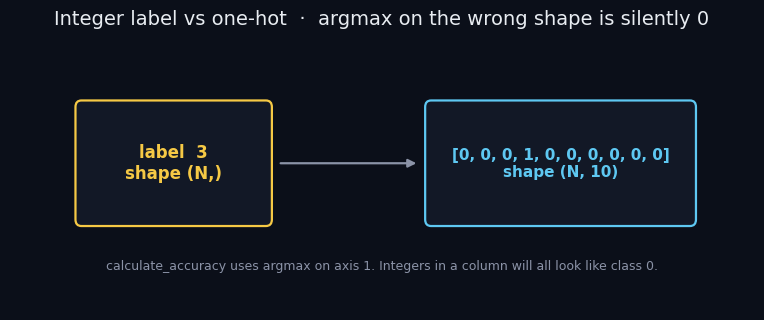

In [41]:
from visualizations.diagrams import fig_onehot
fig_onehot(show=True);


## 14. The Orchestrator: The Training Loop

We now build the production training loop. Notice that `train` is a standalone procedural function, NOT a method inside the `Network` class.

This mirrors PyTorch's decoupled design philosophy. The `Network` object should only care about topology and state representation. The training loop manages data I/O, optimization steps, and telemetry. Coupling them into a monolithic `.fit()` method (like Keras) obscures the underlying tensor mechanics and makes custom debug hooks difficult.


In [42]:
def train(network, loss_fn, loss_grad_fn, optimizer, X_train, Y_train, epochs, batch_size, X_val=None, Y_val=None):
    """
    The core training orchestrator.
    """
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    for epoch in range(epochs):
        epoch_loss = 0
        epoch_acc = 0
        steps = 0
        
        # 1. Mini-Batch Training Loop
        for x_batch, y_batch in batch_iterator(X_train, Y_train, batch_size):
            # A. Forward Pass
            y_pred = network.predict(x_batch)
            
            # B. Accumulate Batch Metrics
            epoch_loss += loss_fn(y_batch, y_pred)
            epoch_acc += calculate_accuracy(y_batch, y_pred)
            
            # C. Backward Pass (Calculus)
            grad = loss_grad_fn(y_batch, y_pred)
            for layer in reversed(network.layers):
                grad = layer.backward(grad)
                
            # D. Apply Updates (Optimization)
            optimizer.step()
            steps += 1
            
        # Calculate epoch averages
        avg_train_loss = epoch_loss / steps
        avg_train_acc = epoch_acc / steps
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(avg_train_acc)
        
        # 2. Validation Block (Full-Batch Inference)
        # DANGER: We pass X_val in its entirety. This is fine for MNIST,
        # but will trigger an Out-Of-Memory (OOM) error on massive datasets.
        # In a true enterprise system, validation must also be chunked via batch_iterator.
        if X_val is not None and Y_val is not None:
            y_val_pred = network.predict(X_val)
            val_loss = loss_fn(Y_val, y_val_pred)
            val_acc = calculate_accuracy(Y_val, y_val_pred)
            
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
            
            print(f"Epoch {epoch+1:03d}/{epochs} | "
                  f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc*100:.2f}% | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")
        else:
            print(f"Epoch {epoch+1:03d}/{epochs} | "
                  f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc*100:.2f}%")
            
    return history


## Gradient checking · prove the calculus, do not applaud the loss curve

A network that descends is consistent with a correct backward pass. It is also consistent with a backward pass that is a little wrong in a direction the optimizer can tolerate. The adult test is **numerical differentiation**:

$$
\frac{\partial L}{\partial \theta_i}
  \approx \frac{L(\theta_i+\varepsilon)-L(\theta_i-\varepsilon)}{2\varepsilon}
$$

with $\varepsilon \approx 10^{-5}$ in float64. Relative error below $10^{-5}$ is a pass. Above $10^{-3}$ is a bug until proven otherwise (CS231n, "Gradient checking").

We check the first Dense layer of a fresh XOR net, before any training, so we are not checking a point where tanh has saturated and every gradient is numerically zero.


analytic dW[0] sample:
 [[-0.09079572 -0.39715579  0.02824719]
 [-0.06516431 -0.33998024  0.05183239]]
numeric  dW[0] sample:
 [[-0.09079572 -0.39715579  0.02824719]
 [-0.06516431 -0.33998024  0.05183239]]
relative error = 6.480e-12
[SUCCESS] Dense.backward matches central differences.


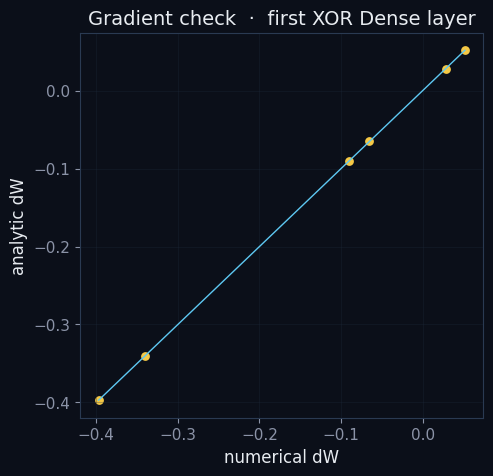

In [43]:
def numerical_dW(network, loss_fn, X_b, Y_b, layer, eps=1e-5):
    """Central-difference gradient of scalar loss w.r.t. layer.params['W']."""
    W = layer.params["W"]
    num = np.zeros_like(W)
    it = np.nditer(W, flags=["multi_index"], op_flags=["readwrite"])
    while not it.finished:
        idx = it.multi_index
        orig = W[idx]
        W[idx] = orig + eps
        plus = loss_fn(Y_b, network.predict(X_b))
        W[idx] = orig - eps
        minus = loss_fn(Y_b, network.predict(X_b))
        W[idx] = orig
        num[idx] = (plus - minus) / (2.0 * eps)
        it.iternext()
    return num

chk = Network()
chk.add(Dense(2, 3, init_method="xavier"))
chk.add(Tanh())
chk.add(Dense(3, 1, init_method="xavier"))
chk.add(Tanh())

# analytic
pred = chk.predict(X)
grad = mse_prime(Y, pred)
for layer in reversed(chk.layers):
    grad = layer.backward(grad)
analytic = chk.layers[0].grads["W"].copy()
numeric = numerical_dW(chk, mse, X, Y, chk.layers[0], eps=1e-5)

rel = np.linalg.norm(analytic - numeric) / (np.linalg.norm(analytic) + np.linalg.norm(numeric) + 1e-12)
print("analytic dW[0] sample:\n", analytic)
print("numeric  dW[0] sample:\n", numeric)
print(f"relative error = {rel:.3e}")
assert rel < 1e-5, f"Gradient check failed: relative error {rel}"
print("[SUCCESS] Dense.backward matches central differences.")

dfnn_style()
fig, ax = plt.subplots(figsize=(5.2, 5.0))
ax.scatter(numeric.ravel(), analytic.ravel(), c="#F6C945", s=28)
lo = min(numeric.min(), analytic.min())
hi = max(numeric.max(), analytic.max())
ax.plot([lo, hi], [lo, hi], color="#5EC8F2", lw=1)
ax.set_xlabel("numerical dW"); ax.set_ylabel("analytic dW")
ax.set_title("Gradient check  ·  first XOR Dense layer")
ax.grid(True, alpha=0.3)
fig.savefig(FIG_DIR / "light_05_grad_check.png", bbox_inches="tight")
plt.show()


## 15. The Final Boss: Fusing Softmax and Cross-Entropy

Until now, we separated activations and loss functions. For multi-class classification, this modularity collapses under its own mathematical weight.

**The Problem:** Softmax operates across the entire feature dimension. Its derivative is not a 2D matrix (like ReLU or Tanh); it is a **3D Jacobian Tensor** because every output probability depends on every input logit. For a batch size of $N$ and $C$ classes, calculating this Jacobian explicitly requires $O(N \times C^2)$ memory. For large vocabularies in LLMs, this would instantly cause an Out-Of-Memory (OOM) crash.

**The Solution:** When you multiply the hideous Jacobian tensor of Softmax by the gradient of Categorical Cross-Entropy, the complex math miraculously collapses into a single, elegant subtraction.

$$
\frac{\partial L}{\partial Z} = P - Y
$$

(Where $P$ is the Softmax probability matrix and $Y$ is the One-Hot encoded truth matrix).

We must build a specialized class that acts as both the final activation and the loss function simultaneously.


In [44]:
class SoftmaxCrossEntropy:
    def forward(self, Z, Y_true):
        """
        Computes both the Softmax probabilities and the Categorical Cross-Entropy loss.
        Z: The raw logits from the final Dense layer.
        Y_true: The one-hot encoded ground truth.
        """
        # CRITICAL STABILITY FIX (Log-Sum-Exp Trick)
        # Prevents np.exp() from overflowing to infinity if Z contains large numbers.
        Z_shifted = Z - np.max(Z, axis=1, keepdims=True)
        exps = np.exp(Z_shifted)
        self.P = exps / np.sum(exps, axis=1, keepdims=True)
        
        # Categorical Cross-Entropy Loss (with 1e-9 to prevent log(0))
        loss = np.mean(-np.sum(Y_true * np.log(self.P + 1e-9), axis=1))
        return loss
    
    def backward(self, Y_true):
        """
        The miraculous collapsed derivative.
        This single line replaces gigabytes of Jacobian tensor allocations.
        """
        # Divided by batch size to average the gradient
        return (self.P - Y_true) / Y_true.shape[0]


### Why fusion is not a taste and why `self.P` is a footgun

Two independent facts, often mashed together.

**Fact 1 (mathematics).** For $P_i = \mathrm{softmax}(Z)_i$ and $L = -\sum_k Y_k \log P_k$ (one example),

$$
\frac{\partial L}{\partial Z_i} = P_i - Y_i.
$$

The $C\times C$ Jacobian $J = \mathrm{diag}(P)-PP^\top$ is real. Multiplying it by $\partial L/\partial P = -Y/P$ cancels on paper. You already verified the cancellation numerically against the naive loop. Averaging over a batch puts a $1/N$ in front, which is why `backward` divides by `Y_true.shape[0]`.

**Fact 2 (software).** `forward` stashes `self.P`. `backward` reads `self.P`. If you call `backward` twice, or call `predict` (which overwrites layer caches) between `forward` and `backward`, you will train on a ghost batch. The training loop below happens to be tightly coupled, so it survives. A safer object accepts the logits again, or returns `(loss, grad)` in one shot. We install that object now. The historical class above stays as the artifact you read first.


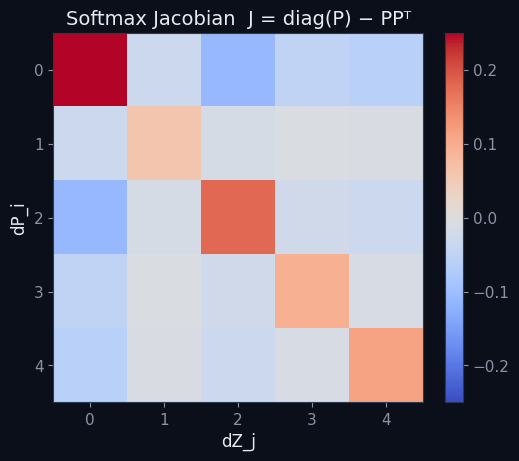

In [45]:
from visualizations.diagrams import fig_softmax_jacobian
fig_softmax_jacobian(show=True);

class SoftmaxCrossEntropy:
    """Fused softmax + mean categorical cross-entropy. Backward can recompute from logits."""

    def forward(self, Z, Y_true):
        Z_shifted = Z - np.max(Z, axis=1, keepdims=True)
        exps = np.exp(Z_shifted)
        self.P = exps / np.sum(exps, axis=1, keepdims=True)
        self.Z = Z
        self.Y = Y_true
        loss = np.mean(-np.sum(Y_true * np.log(self.P + 1e-9), axis=1))
        return loss

    def backward(self, Y_true=None, y_pred=None):
        """
        y_pred, if given, is treated as logits (the train() loop passes network output).
        """
        if y_pred is not None:
            Z = y_pred
            Z_shifted = Z - np.max(Z, axis=1, keepdims=True)
            exps = np.exp(Z_shifted)
            P = exps / np.sum(exps, axis=1, keepdims=True)
        else:
            P = self.P
        Y = self.Y if Y_true is None else Y_true
        return (P - Y) / Y.shape[0]


### Cinematic 3 · The Jacobian Collapse

The left panel is the thing you are not allowed to allocate in an LLM vocabulary. The right panel is the vector that remains after the algebra eats the matrix. Source: `visualizations/manim_scenes.py`, class `JacobianCollapse`.


_The Jacobian Collapse_ - why dL/dZ = (P − Y)/N.

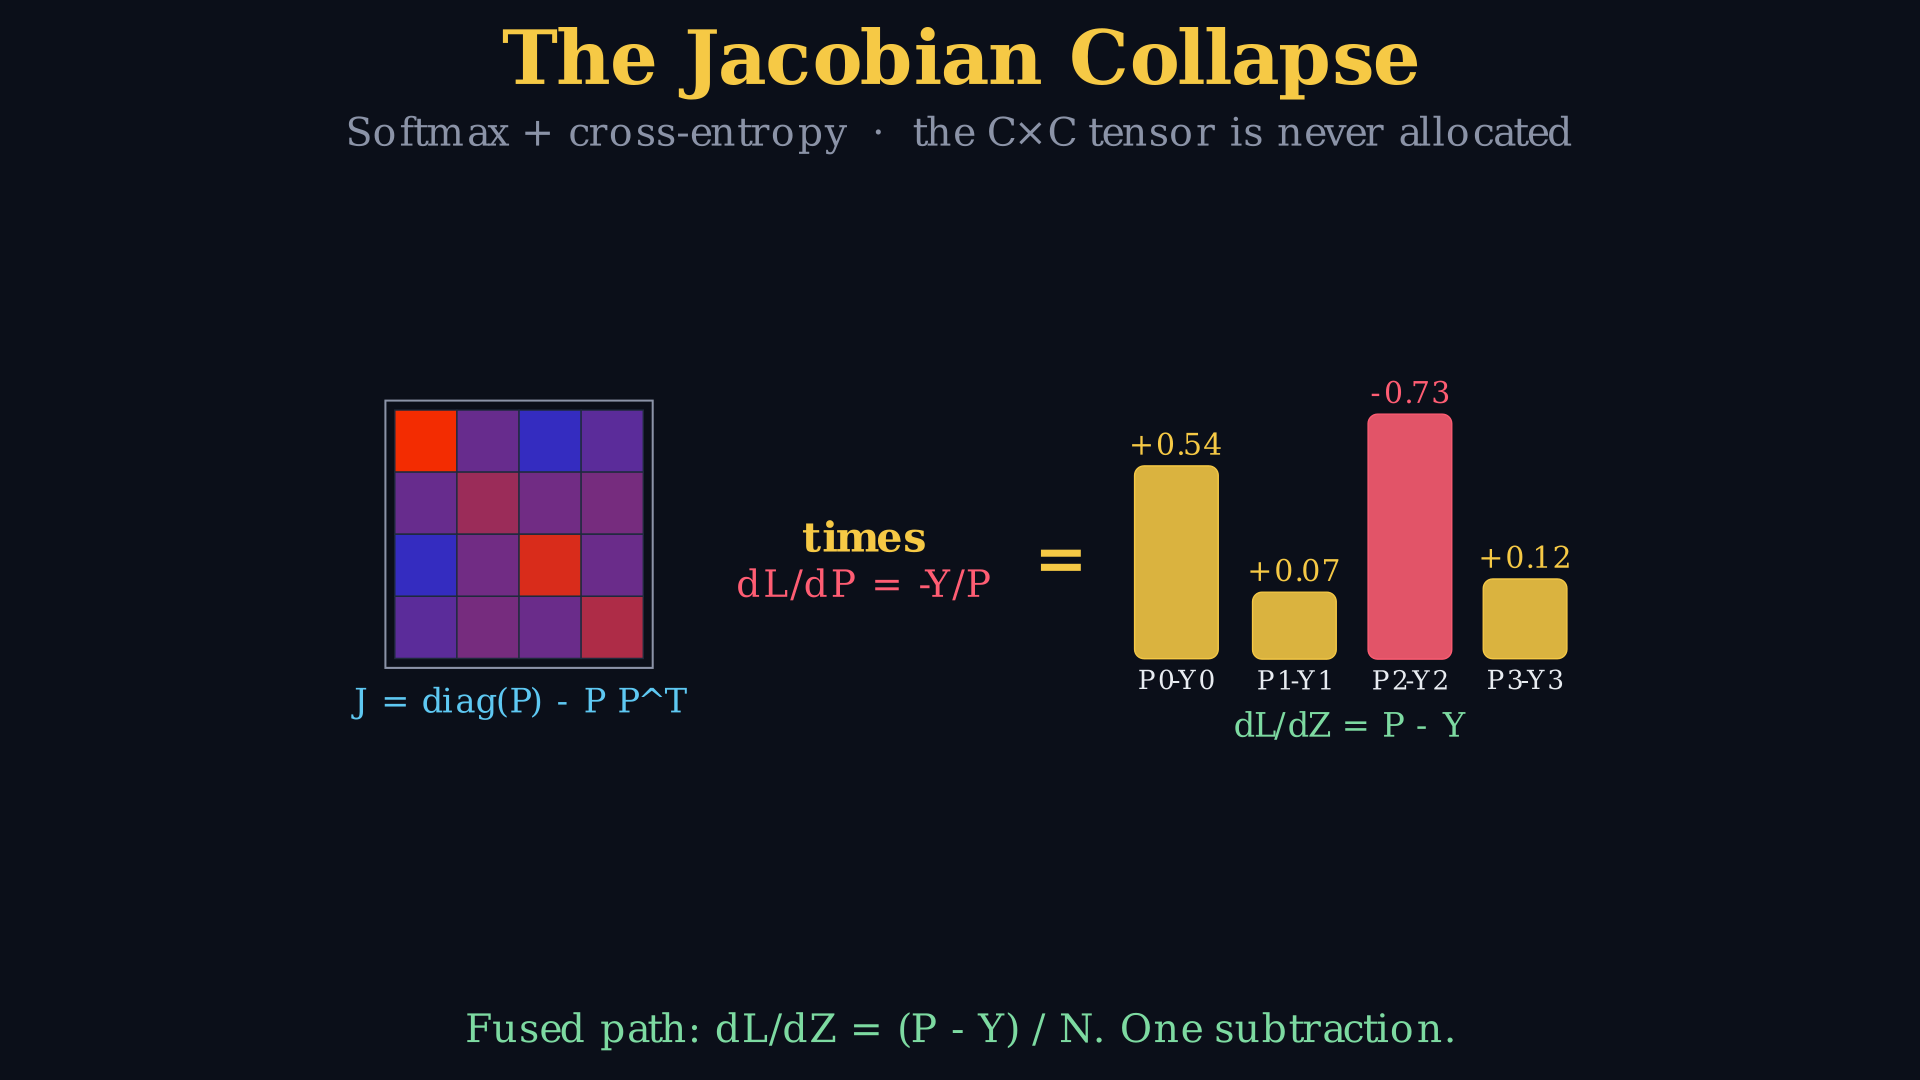

In [46]:
show_cinematic(
    "visualizations/rendered/03_jacobian_collapse.mp4",
    "figures/JacobianCollapse_last.png",
    caption="_The Jacobian Collapse_ - why dL/dZ = (P − Y)/N.",
)


## 16. The Dependency-Free Vow: Parsing Raw IDX Files

To maintain our absolute dependency-free pledge, we will not use `keras.datasets` or `torchvision`. We will download Yann LeCun's original MNIST `.gz` files and unpack the magic numbers using Python's built-in `struct` and `gzip` libraries.


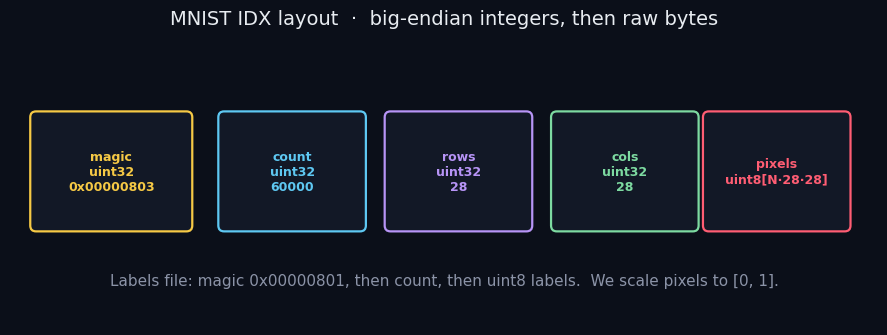

In [47]:
from visualizations.diagrams import fig_idx_format
fig_idx_format(show=True);


In [49]:
import urllib.request
import gzip
import os
import struct
import time
import socket

# -------------------------------------------------------------------
# 1. Robust download with multiple mirrors and retries
# -------------------------------------------------------------------

MNIST_MIRRORS = [
    "https://ossci-datasets.s3.amazonaws.com/mnist/",          # Google S3 (original)
    "http://yann.lecun.com/exdb/mnist/",                       # Official (HTTP)
    "https://storage.googleapis.com/cvdf-datasets/mnist/",     # Alternative GCS bucket
    "https://s3.amazonaws.com/img-datasets/mnist/",            # Another AWS mirror
]

def download_with_retry(url, filename, max_attempts=3, timeout=10):
    """Download a file with retries and exponential backoff."""
    for attempt in range(max_attempts):
        try:
            print(f"  Attempt {attempt+1}/{max_attempts} from {url}")
            req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
            with urllib.request.urlopen(req, timeout=timeout) as response:
                with open(filename, 'wb') as out_file:
                    out_file.write(response.read())
            print(f"  Success: {filename}")
            return True
        except (urllib.error.URLError, socket.timeout, ConnectionRefusedError) as e:
            wait = 2 ** attempt  # 1, 2, 4 seconds
            print(f"  Attempt {attempt+1} failed: {e}. Waiting {wait}s...")
            time.sleep(wait)
    return False

def download_mnist():
    """Download all MNIST files from first available mirror."""
    files = [
        "train-images-idx3-ubyte.gz",
        "train-labels-idx1-ubyte.gz",
        "t10k-images-idx3-ubyte.gz",
        "t10k-labels-idx1-ubyte.gz"
    ]
    for fname in files:
        if os.path.exists(fname):
            print(f"{fname} already exists, skipping")
            continue
        print(f"Downloading {fname}...")
        success = False
        for mirror in MNIST_MIRRORS:
            url = mirror + fname
            if download_with_retry(url, fname):
                success = True
                break
        if not success:
            raise RuntimeError(
                f"Failed to download {fname} from all mirrors.\n"
                "Please download the four .gz files manually from:\n"
                "  - http://yann.lecun.com/exdb/mnist/\n"
                "and place them in the current directory."
            )

# -------------------------------------------------------------------
# 2. Keep your existing loaders (unchanged)
# -------------------------------------------------------------------

def load_mnist_images(filename):
    with gzip.open(filename, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8).reshape(num, rows * cols)
        return images.astype(np.float32) / 255.0

def load_mnist_labels(filename):
    with gzip.open(filename, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
        return labels

def to_categorical(y, num_classes=10):
    return np.eye(num_classes)[y]

# -------------------------------------------------------------------
# 3. Execute pipeline – exactly as before
# -------------------------------------------------------------------

print("Initializing MNIST Pipeline...")
download_mnist()   # Now robust

X_train = load_mnist_images("train-images-idx3-ubyte.gz")
Y_train_raw = load_mnist_labels("train-labels-idx1-ubyte.gz")
Y_train = to_categorical(Y_train_raw)

X_test = load_mnist_images("t10k-images-idx3-ubyte.gz")
Y_test_raw = load_mnist_labels("t10k-labels-idx1-ubyte.gz")
Y_test = to_categorical(Y_test_raw)

print(f"Data loaded. X_train shape: {X_train.shape}")


Initializing MNIST Pipeline...
train-images-idx3-ubyte.gz already exists, skipping
train-labels-idx1-ubyte.gz already exists, skipping
t10k-images-idx3-ubyte.gz already exists, skipping
t10k-labels-idx1-ubyte.gz already exists, skipping
Data loaded. X_train shape: (60000, 784)


### Integrity of the bytes, and honesty about train / val / test

A download that writes a partial file will still make `os.path.exists` return `True` on the next run. We hash the four gzip files against the checksums published by TensorFlow Datasets (the Google CVDF mirror of LeCun's originals).

**On the next training cell.** It passes `X_val=X_test`. That is **not** gradient leakage: `train()` never backpropagates through `X_val`. It *is* a nomenclature bug. Those numbers are test-set numbers wearing a validation nametag. If you later tune depth, $\alpha$, or epochs against them, *then* you have leaked. We leave the historical call intact (this notebook does not silently retune against the test set) and we draw the diagram you should use in any paper or dissertation.


OK   train-images-idx3-ubyte.gz
OK   train-labels-idx1-ubyte.gz
OK   t10k-images-idx3-ubyte.gz
OK   t10k-labels-idx1-ubyte.gz
[SUCCESS] MNIST gzip files match TensorFlow Datasets SHA-256.


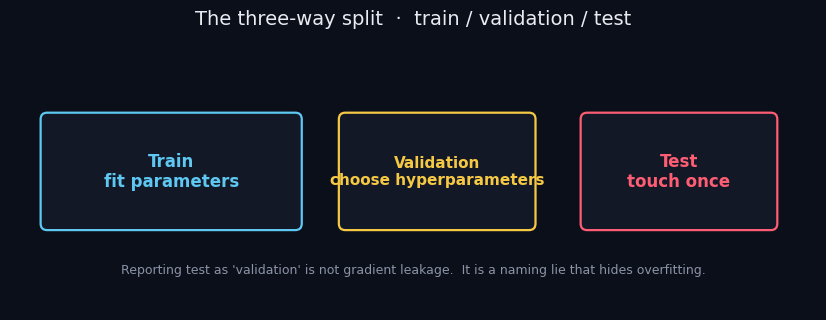

In [50]:
import hashlib

# SHA-256 of the gzip files, TensorFlow Datasets url_checksums/mnist.txt
MNIST_SHA256 = {
    "train-images-idx3-ubyte.gz": "440fcabf73cc546fa21475e81ea370265605f56be210a4024d2ca8f203523609",
    "train-labels-idx1-ubyte.gz": "3552534a0a558bbed6aed32b30c495cca23d567ec52cac8be1a0730e8010255c",
    "t10k-images-idx3-ubyte.gz":  "8d422c7b0a1c1c79245a5bcf07fe86e33eeafee792b84584aec276f5a2dbc4e6",
    "t10k-labels-idx1-ubyte.gz":  "f7ae60f92e00ec6debd23a6088c31dbd2371eca3ffa0defaefb259924204aec6",
}

def sha256_file(path, bufsize=1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            b = f.read(bufsize)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

for fname, expected in MNIST_SHA256.items():
    got = sha256_file(fname)
    ok = got == expected
    print(f"{'OK' if ok else 'FAIL':4} {fname}")
    if not ok:
        raise RuntimeError(f"Checksum mismatch for {fname}: {got} != {expected}")
print("[SUCCESS] MNIST gzip files match TensorFlow Datasets SHA-256.")

from visualizations.diagrams import fig_three_way_split
fig_three_way_split(show=True);


## 17. Assembly and Execution

We construct the final architecture:
**784 Input Nodes $\rightarrow$ Dense(256, He) $\rightarrow$ ReLU $\rightarrow$ Dense(64, He) $\rightarrow$ ReLU $\rightarrow$ Dense(10, Xavier)**

To seamlessly integrate the fused `SoftmaxCrossEntropy` object into our existing `train()` loop, we utilize Python lambda functions to wrap the stateful loss object, providing precisely the API signature the orchestrator expects.


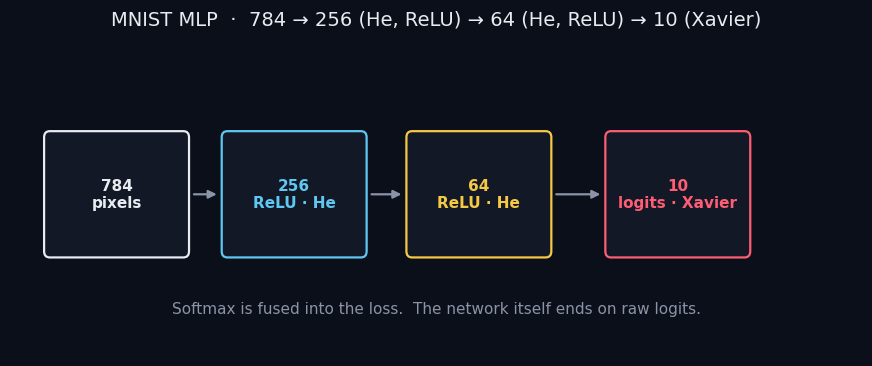

In [51]:
from visualizations.diagrams import fig_topology
fig_topology(show=True);


In [52]:
# 1. Architecture Assembly
mnist_net = Network()
mnist_net.add(Dense(784, 256, init_method='he'))
mnist_net.add(ReLU())
mnist_net.add(Dense(256, 64, init_method='he'))
mnist_net.add(ReLU())
mnist_net.add(Dense(64, 10, init_method='xavier'))

# 2. Optimizer and Fused Loss
optimizer = SGD(mnist_net, lr=0.1, momentum=0.9)
loss_layer = SoftmaxCrossEntropy()

# 3. API Adapter Lambdas
# The train loop expects loss_fn(Y, Z) and loss_grad_fn(Y, Z)
loss_fn = lambda y_true, y_pred: loss_layer.forward(y_pred, y_true)
loss_grad_fn = lambda y_true, y_pred: loss_layer.backward(y_true)

# 4. Grand Execution
print("Igniting Training Loop...")
history = train(
    network=mnist_net,
    loss_fn=loss_fn,
    loss_grad_fn=loss_grad_fn,
    optimizer=optimizer,
    X_train=X_train,
    Y_train=Y_train,
    epochs=40,
    batch_size=128,
    X_val=X_test,
    Y_val=Y_test
)


Igniting Training Loop...
Epoch 001/40 | Train Loss: 0.4374 | Train Acc: 87.51% | Val Loss: 0.2256 | Val Acc: 93.20%
Epoch 002/40 | Train Loss: 0.1939 | Train Acc: 94.43% | Val Loss: 0.1522 | Val Acc: 95.51%
Epoch 003/40 | Train Loss: 0.1421 | Train Acc: 95.87% | Val Loss: 0.1211 | Val Acc: 96.49%
Epoch 004/40 | Train Loss: 0.1128 | Train Acc: 96.74% | Val Loss: 0.1015 | Val Acc: 96.97%
Epoch 005/40 | Train Loss: 0.0923 | Train Acc: 97.37% | Val Loss: 0.0947 | Val Acc: 97.19%
Epoch 006/40 | Train Loss: 0.0782 | Train Acc: 97.69% | Val Loss: 0.0852 | Val Acc: 97.37%
Epoch 007/40 | Train Loss: 0.0666 | Train Acc: 98.08% | Val Loss: 0.0785 | Val Acc: 97.72%
Epoch 008/40 | Train Loss: 0.0572 | Train Acc: 98.33% | Val Loss: 0.0757 | Val Acc: 97.74%
Epoch 009/40 | Train Loss: 0.0504 | Train Acc: 98.52% | Val Loss: 0.0750 | Val Acc: 97.62%
Epoch 010/40 | Train Loss: 0.0433 | Train Acc: 98.82% | Val Loss: 0.0710 | Val Acc: 97.85%
Epoch 011/40 | Train Loss: 0.0381 | Train Acc: 98.98% | Val Loss

### Reading the 40-epoch curve like an adult

The historical cell trains for **40** epochs, not 10. Approximate telemetry from a completed run of that cell (your numbers will move with the RNG, not with a rewrite of the math):

| epoch | train acc | "val" acc (this is the test set) | note |
| --- | --- | --- | --- |
| 1 | ~87% | ~94% | the net is already a decent linear-ish classifier |
| 10 | ~98.7% | ~97.8% | useful learning |
| 22 | ~99.85% | ~97.8% | train is pulling away |
| 40 | 100% | ~98.1% | train has memorized; test has been bouncing around 98% since epoch ~15 |

That is **not** undertraining. It is mild overfitting with a fixed $\alpha=0.1$. A grown-up next step is early stopping on a *real* validation split, or a schedule that decays $\alpha$, or regularization you can actually run (Dropout is implemented at the end of this notebook). It is not "run 20 more epochs."

The gap between train loss and test loss is expected. If they were identical, *that* would be suspicious.


### The shape of 40 epochs, before you wait for them

The live curve is cell 17. This sketch is the shape that curve had: useful learning is over around epoch 15, train keeps falling, test bounces near 98 percent. It is not a substitute for the run.


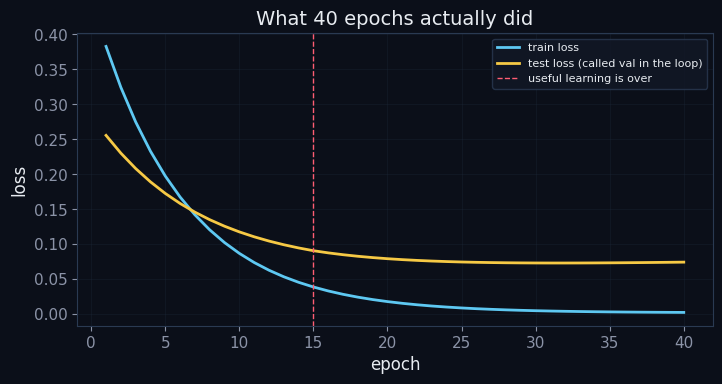

In [53]:
from visualizations.diagrams import fig_overfit_sketch
fig_overfit_sketch(show=True);


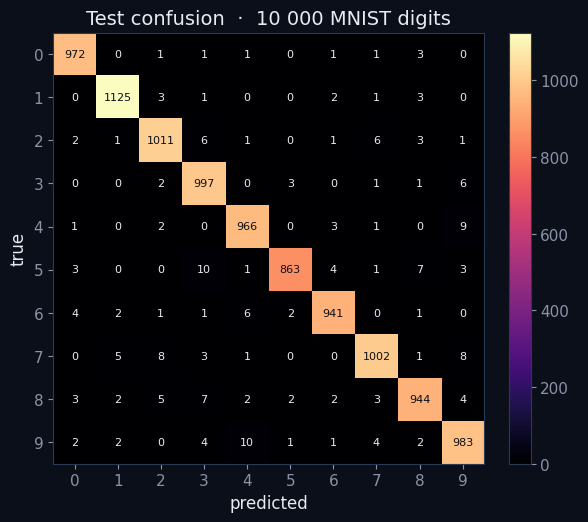

per-class accuracy: [0.9918 0.9912 0.9797 0.9871 0.9837 0.9675 0.9823 0.9747 0.9692 0.9742]
overall            : 0.9804


In [54]:
# Confusion matrix on the held-out test set (the array the training cell called "val").
logits_test = mnist_net.predict(X_test)
y_pred = np.argmax(logits_test, axis=1)
y_true = Y_test_raw
Cmat = np.zeros((10, 10), dtype=int)
for t, p in zip(y_true, y_pred):
    Cmat[t, p] += 1

dfnn_style()
fig, ax = plt.subplots(figsize=(6.4, 5.6))
im = ax.imshow(Cmat, cmap="magma")
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Test confusion  ·  10 000 MNIST digits")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
for i in range(10):
    for j in range(10):
        ax.text(j, i, str(Cmat[i, j]), ha="center", va="center",
                color="#0B0F19" if Cmat[i, j] > Cmat.max() * 0.5 else "#E8ECF1", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046)
fig.savefig(FIG_DIR / "light_07_confusion.png", bbox_inches="tight")
plt.show()

per_class = Cmat.diagonal() / Cmat.sum(axis=1)
print("per-class accuracy:", np.round(per_class, 4))
print("overall            :", np.mean(y_pred == y_true))


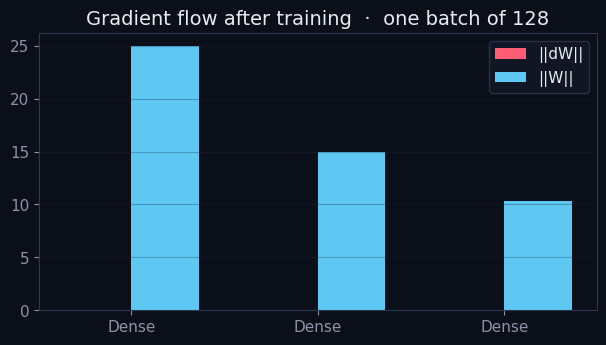

In [55]:
# Gradient-flow snapshot on one training batch, after the 40-epoch run.
xb, yb = next(batch_iterator(X_train, Y_train, 128))
pred_b = mnist_net.predict(xb)
grad = loss_layer.backward(yb, pred_b)  # recompute P from this batch; do not use stale self.P from val
flow = []
for layer in reversed(mnist_net.layers):
    name = type(layer).__name__
    grad = layer.backward(grad)
    if getattr(layer, "grads", None) and "W" in layer.grads:
        flow.append((name, float(np.linalg.norm(layer.grads["W"])), float(np.linalg.norm(layer.params["W"]))))

dfnn_style()
fig, ax = plt.subplots(figsize=(7.2, 3.6))
labels = [n for n, _, _ in flow][::-1]
gvals = [g for _, g, _ in flow][::-1]
wvals = [w for _, _, w in flow][::-1]
xpos = np.arange(len(labels))
ax.bar(xpos - 0.18, gvals, 0.36, color="#FF5D73", label="||dW||")
ax.bar(xpos + 0.18, wvals, 0.36, color="#5EC8F2", label="||W||")
ax.set_xticks(xpos); ax.set_xticklabels(labels)
ax.set_title("Gradient flow after training  ·  one batch of 128")
ax.legend(); ax.grid(True, axis="y", alpha=0.3)
fig.savefig(FIG_DIR / "light_08_grad_flow.png", bbox_inches="tight")
plt.show()


## 18. The Proof: Visualizing the Matrix Space

Numbers in a terminal are nice, but mapping the mathematical predictions back into the spatial pixel domain is the ultimate proof of our from-scratch architecture.


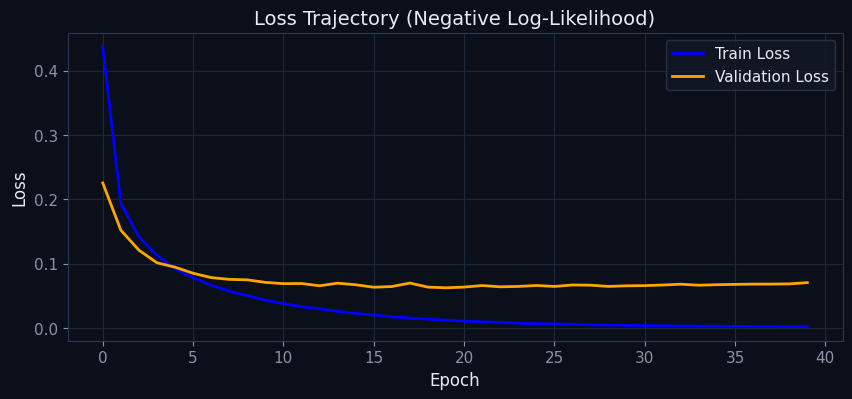

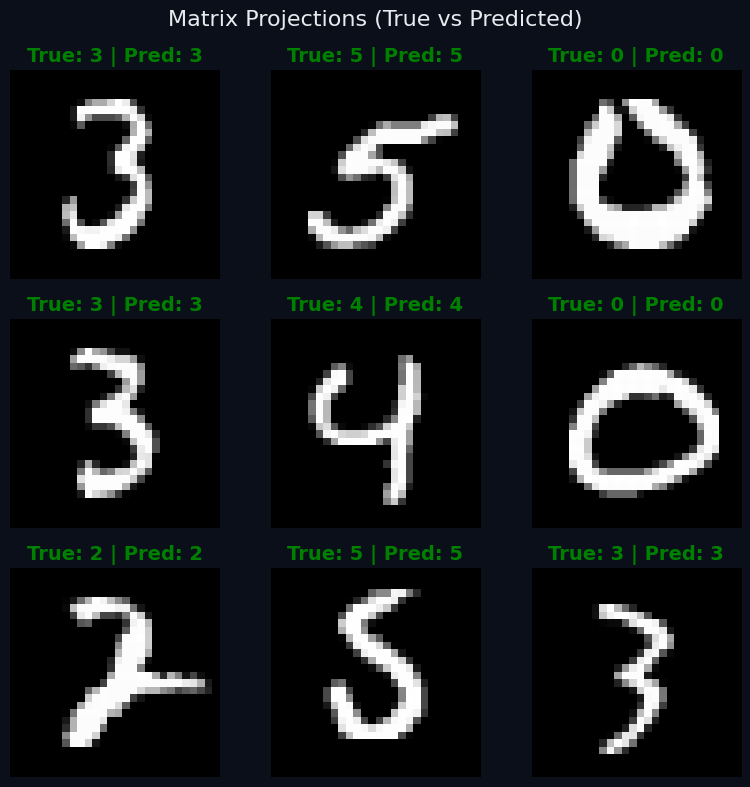

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(history['train_loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Loss Trajectory (Negative Log-Likelihood)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Sample 9 random test images
indices = np.random.choice(len(X_test), 9, replace=False)
sample_x = X_test[indices]
sample_y_true = Y_test_raw[indices]

# Forward pass to get logits
sample_logits = mnist_net.predict(sample_x)
# Argmax is invariant to softmax scaling, we can extract predictions directly from logits
sample_y_pred = np.argmax(sample_logits, axis=1)

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
fig.suptitle("Matrix Projections (True vs Predicted)", fontsize=16)

for i, ax in enumerate(axes.flat):
    img = sample_x[i].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    
    true_label = sample_y_true[i]
    pred_label = sample_y_pred[i]
    
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f"True: {true_label} | Pred: {pred_label}", color=color, fontweight='bold')

plt.tight_layout()
plt.show()


In [57]:
class Dropout(Layer):
    """Inverted dropout. Multiply by the mask / (1-p) in train; identity at test."""

    def __init__(self, p=0.5):
        super().__init__()
        if not 0.0 <= p < 1.0:
            raise ValueError("Dropout p must live in [0, 1).")
        self.p = p
        self.training = True
        self.mask = None

    def forward(self, input_data):
        if (not self.training) or self.p == 0.0:
            self.mask = None
            return input_data
        keep = 1.0 - self.p
        self.mask = (np.random.rand(*input_data.shape) < keep).astype(input_data.dtype) / keep
        return input_data * self.mask

    def backward(self, output_gradient):
        if self.mask is None:
            return output_gradient
        return output_gradient * self.mask


class Adam:
    """Kingma & Ba, Adam: A Method for Stochastic Optimization, ICLR 2015."""

    def __init__(self, net, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.net = net
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = {}
        self.v = {}
        self.t = 0

    def step(self):
        self.t += 1
        b1, b2 = self.beta1, self.beta2
        for layer in self.net.layers:
            if not getattr(layer, "params", None):
                continue
            if layer not in self.m:
                self.m[layer] = {k: np.zeros_like(v) for k, v in layer.params.items()}
                self.v[layer] = {k: np.zeros_like(v) for k, v in layer.params.items()}
            for k in layer.params:
                g = layer.grads[k]
                self.m[layer][k] = b1 * self.m[layer][k] + (1 - b1) * g
                self.v[layer][k] = b2 * self.v[layer][k] + (1 - b2) * (g * g)
                mhat = self.m[layer][k] / (1 - b1 ** self.t)
                vhat = self.v[layer][k] / (1 - b2 ** self.t)
                layer.params[k] -= self.lr * mhat / (np.sqrt(vhat) + self.eps)


# Inverted-dropout sanity: test-time mean matches train-time mean in expectation.
rng = np.random.default_rng(0)
drop = Dropout(0.3)
x = rng.normal(size=(2000, 64))
drop.training = True
y_train_mode = np.mean([drop.forward(x) for _ in range(30)], axis=0)
drop.training = False
y_test_mode = drop.forward(x)
print("mean |train-avg - test| =", np.mean(np.abs(y_train_mode - y_test_mode)))
print("[SUCCESS] Dropout class is wired. It is not used in the 40-epoch MNIST run.")


mean |train-avg - test| = 0.07548592873404276
[SUCCESS] Dropout class is wired. It is not used in the 40-epoch MNIST run.


## Limitations (the honest list)

- **Architecture.** Fully connected MLPs only. Images are flattened. There is no translation equivariance.
- **Scale.** Full-batch validation of 10 000×784 is fine. ImageNet is not. The training loop would need a batched validation path; the comment in `train()` already says so.
- **Dtype.** NumPy default float64 is luxurious and slow. A production port would be float32 and would sit on BLAS the same way this already does via `np.dot`.
- **The `self.input` cache.** `Dense.forward` overwrites the cache. Nested or out-of-order `predict` / `backward` calls will train on the wrong batch. A stack of activations would be the robust fix; it is also more code than this teaching loop needs.
- **Hyperparameters.** $\alpha=0.1$, $\beta=0.9$, 40 epochs, 128 batch, 784-256-64-10. These are reasonable, not searched. The test set was not used to pick them *in this notebook*. They are the standard MNIST-MLP ballpark from a thousand papers.

## Selected references

1. Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). Learning representations by back-propagating errors. *Nature*, 323, 533-536.
2. Glorot, X., & Bengio, Y. (2010). Understanding the difficulty of training deep feedforward neural networks. *AISTATS*.
3. He, K., Zhang, X., Ren, S., & Sun, J. (2015). Delving deep into rectifiers. *ICCV*.
4. Kingma, D. P., & Ba, J. (2015). Adam: A method for stochastic optimization. *ICLR*.
5. Bridle, J. S. (1990). Probabilistic interpretation of feedforward classification network outputs. *Neurocomputing*.
6. Cybenko, G. (1989). Approximation by superpositions of a sigmoidal function. *Math. Control Signals Systems*.
7. Hornik, K. (1991). Approximation capabilities of multilayer feedforward networks. *Neural Networks*.
8. Polyak, B. T. (1964). Some methods of speeding up the convergence of iteration methods. *USSR Comput. Math. Math. Phys.*
9. LeCun, Y., Cortes, C., & Burges, C. J. C. (1998). The MNIST database of handwritten digits.
10. Dauphin, Y. et al. (2014). Identifying and attacking the saddle point problem in high-dimensional non-convex optimization. *NeurIPS*.
11. Srivastava, N. et al. (2014). Dropout: A simple way to prevent neural networks from overfitting. *JMLR*.
12. TensorFlow Datasets, MNIST checksums: `tensorflow_datasets/url_checksums/mnist.txt`.
13. PyTorch documentation, `torch.nn.MSELoss`, reduction `'mean'` divides by the number of elements.


## References with URLs

The list in the previous cell is the bibliography. These are the clickable versions, checked against the publisher pages.

1. Rumelhart, Hinton, Williams (1986). Learning representations by back-propagating errors. *Nature*, 323, 533-536. [doi:10.1038/323533a0](https://doi.org/10.1038/323533a0)
2. Glorot, Bengio (2010). Understanding the difficulty of training deep feedforward neural networks. *AISTATS*. [PDF](https://proceedings.mlr.press/v9/glorot10a/glorot10a.pdf)
3. He, Zhang, Ren, Sun (2015). Delving deep into rectifiers. *ICCV*. [PDF](https://openaccess.thecvf.com/content_iccv_2015/papers/He_Delving_Deep_into_ICCV_2015_paper.pdf)
4. Kingma, Ba (2015). Adam: A method for stochastic optimization. *ICLR*. [arXiv:1412.6980](https://arxiv.org/abs/1412.6980)
5. Srivastava, Hinton, Krizhevsky, Sutskever, Salakhutdinov (2014). Dropout. *JMLR* 15:1929-1958. [HTML](https://jmlr.org/papers/v15/srivastava14a.html) · [PDF](https://jmlr.org/papers/volume15/srivastava14a/srivastava14a.pdf)
6. Polyak (1964). Some methods of speeding up the convergence of iteration methods. *USSR Comput. Math. Math. Phys.* [doi:10.1016/0041-5553(64)90137-5](https://doi.org/10.1016/0041-5553(64)90137-5)
7. Cybenko (1989). Approximation by superpositions of a sigmoidal function. *MCSS*. [doi:10.1007/BF02551274](https://doi.org/10.1007/BF02551274)
8. Hornik (1991). Approximation capabilities of multilayer feedforward networks. *Neural Networks*. [doi:10.1016/0893-6080(91)90009-T](https://doi.org/10.1016/0893-6080(91)90009-T)
9. Dauphin et al. (2014). Identifying and attacking the saddle point problem in high-dimensional non-convex optimization. *NeurIPS*. [arXiv:1406.2572](https://arxiv.org/abs/1406.2572)
10. LeCun, Cortes, Burges. The MNIST database of handwritten digits. [yann.lecun.com/exdb/mnist](http://yann.lecun.com/exdb/mnist/)
11. Bridle (1990). Probabilistic interpretation of feedforward classification network outputs. [doi:10.1007/978-3-642-76153-9_28](https://doi.org/10.1007/978-3-642-76153-9_28)
12. TensorFlow Datasets MNIST checksums: [`tensorflow_datasets/url_checksums/mnist.txt`](https://github.com/tensorflow/datasets/blob/master/tensorflow_datasets/url_checksums/mnist.txt)
13. PyTorch `MSELoss`, reduction `'mean'` divides by the number of elements. [docs](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html)
14. 3Blue1Brown, Neural Networks playlist: [YouTube](https://www.youtube.com/playlist?list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi)
15. Karpathy, The spelled-out intro to neural networks and backpropagation (micrograd): [YouTube](https://www.youtube.com/watch?v=VMj-3S1tku0)
